In [1]:
# ============================================================
# Cell 0.1 — Imports and global config
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations

from sklearn.linear_model import LinearRegression
from statsmodels.graphics.tsaplots import plot_acf

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "figure.autolayout": True,
})
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
np.set_printoptions(precision=4, suppress=True)

# ---------- USER CONFIG ----------
CSV_PATH     = "03_swarm_static_2m.csv"
DIST_COL     = "dist_calib_m"        # input signal to model
TEST_FRAC    = 0.20                  # holdout fraction
RANDOM_SEED  = 42
FIT_DEVICES  = [2, 3, 4]             # R1 excluded (see Section 7)
DEVICES_ALL  = [1, 2, 3, 4]
OUT_DIR      = Path("thermal_drift_final")
OUT_DIR.mkdir(exist_ok=True)
print("Config OK. Output dir:", OUT_DIR.resolve())

Config OK. Output dir: /home/homayoon/anjoman-firmware/analysis/12_swarm_static_2m/thermal_drift_final


In [2]:
# ============================================================
# Cell 1.1 — Load, clean, normalise link direction
# ============================================================
df = pd.read_csv(CSV_PATH)
print(f"loaded rows: {len(df)}")

if "status" in df.columns:
    df = df[df["status"] == 1].copy()
    print(f"after status==1 filter: {len(df)}")

df = df.dropna(subset=["temp_uwb_init", "temp_uwb_resp", DIST_COL]).reset_index(drop=True)

# Ensure i_id < j_id so each link appears once
flip = df["init_id"] > df["resp_id"]
df["i_id"] = np.where(flip, df["resp_id"], df["init_id"]).astype(int)
df["j_id"] = np.where(flip, df["init_id"], df["resp_id"]).astype(int)
df["Ti"]   = np.where(flip, df["temp_uwb_resp"], df["temp_uwb_init"])
df["Tj"]   = np.where(flip, df["temp_uwb_init"], df["temp_uwb_resp"])
df["link"] = df["i_id"].astype(str) + "-" + df["j_id"].astype(str)
df["t"]    = (df["timestamp_ms"] - df["timestamp_ms"].min()) / 1000.0

# Mean-centred distance per link (removes d_ij + b_i + b_j)
df["dr"] = df[DIST_COL] - df.groupby("link")[DIST_COL].transform("mean")

print(f"links   : {sorted(df['link'].unique())}")
print(f"frames  : {df['frame_id'].nunique()}")
print(f"duration: {df['t'].max():.1f} s")

loaded rows: 19080
after status==1 filter: 19014
links   : ['1-2', '1-3', '1-4', '2-3', '2-4', '3-4']
frames  : 3180
duration: 635.8 s


In [3]:
# Cell 1.2 — Drop bad rows and reorder init<resp
if "status" in df.columns:
    print("status counts:", df["status"].value_counts().to_dict())
    df = df[df["status"] == 1].copy()

df = df.dropna(subset=["temp_uwb_init", "temp_uwb_resp"]).reset_index(drop=True)

# Order i<j
flip = df["init_id"] > df["resp_id"]
df["i_id"] = np.where(flip, df["resp_id"], df["init_id"]).astype(int)
df["j_id"] = np.where(flip, df["init_id"], df["resp_id"]).astype(int)
df["Ti"]   = np.where(flip, df["temp_uwb_resp"], df["temp_uwb_init"])
df["Tj"]   = np.where(flip, df["temp_uwb_init"], df["temp_uwb_resp"])
df["link"] = df["i_id"].astype(str) + "-" + df["j_id"].astype(str)
df["t"]    = (df["timestamp_ms"] - df["timestamp_ms"].min()) / 1000.0

print(f"\nlinks: {sorted(df['link'].unique())}")
print(f"frames: {df['frame_id'].nunique()}")
print(f"duration: {df['t'].max():.1f} s")

status counts: {1: 19014, 0: 66}

links: ['1-2', '1-3', '1-4', '2-3', '2-4', '3-4']
frames: 3180
duration: 635.8 s


In [3]:
# ============================================================
# Cell 2.1 — Per-link summary
# ============================================================
GT = {"1-2": 2.0000, "1-3": 2.8284, "1-4": 2.0000,
      "2-3": 2.0000, "2-4": 2.8284, "3-4": 2.0000}

print(f"{'link':6s} {'GT':>6s} {'mean':>10s} {'std[cm]':>10s} {'n':>6s}")
print("-" * 45)
for link, g in df.groupby("link"):
    print(f"{link:6s} {GT[link]:6.3f} "
          f"{g[DIST_COL].mean():10.4f} "
          f"{g[DIST_COL].std()*100:10.3f} "
          f"{len(g):6d}")

link       GT       mean    std[cm]      n
---------------------------------------------
1-2     2.000   -20.4910    140.823   3144
1-3     2.828   -15.6616     90.084   3179
1-4     2.000   -19.0307    134.192   3179
2-3     2.000    14.0330     57.142   3164
2-4     2.828     1.7295     14.434   3180
3-4     2.000    -0.4607     39.975   3168


In [4]:
# Cell 2.1 — Per-link summary for each distance column
dist_cols = [c for c in df.columns if c.startswith("dist_")]
print("Distance columns found:", dist_cols)

summary = []
for link, g in df.groupby("link"):
    row = {"link": link, "n": len(g)}
    for c in dist_cols:
        row[f"{c}_mean"] = g[c].mean()
        row[f"{c}_std"]  = g[c].std()
    summary.append(row)

summary_df = pd.DataFrame(summary)
summary_df.round(4)

Distance columns found: ['dist_uncomp_m', 'dist_clock_m', 'dist_rssi_m', 'dist_calib_m']


,link,n,dist_uncomp_m_mean,dist_uncomp_m_std,dist_clock_m_mean,dist_clock_m_std,dist_rssi_m_mean,dist_rssi_m_std,dist_calib_m_mean,dist_calib_m_std
0,1-2,3144,21.1344,0.6993,1.5661,1.4151,1.4288,1.4082,-20.4910,1.4082
1,1-3,3179,24.5652,0.4447,7.5847,0.9165,7.5096,0.9008,-15.6616,0.9008
2,1-4,3179,21.6372,0.6643,2.6642,1.3498,2.5151,1.3419,-19.0307,1.3419
3,2-3,3164,43.1574,0.3000,45.7125,0.5700,45.5290,0.5714,14.0330,0.5714
4,2-4,3180,42.1689,0.0793,42.7332,0.1375,42.5951,0.1443,1.7295,0.1443
5,3-4,3168,38.9863,0.1944,36.9626,0.4190,36.8810,0.3998,-0.4607,0.3998


In [5]:
# ============================================================
# Cell 2.2 — Temperature range per device
# ============================================================
print("Per-device UWB chip temperature (°C):")
print(f"{'dev':>4s} {'min':>7s} {'max':>7s} {'mean':>7s} {'span':>7s}")
for d in DEVICES_ALL:
    Ts = pd.concat([
        df.loc[df["i_id"] == d, "Ti"],
        df.loc[df["j_id"] == d, "Tj"],
    ])
    print(f"{d:>4d} {Ts.min():7.2f} {Ts.max():7.2f} "
          f"{Ts.mean():7.2f} {Ts.max()-Ts.min():7.2f}")

Per-device UWB chip temperature (°C):
 dev     min     max    mean    span
   1   43.90   54.90   52.24   11.00
   2   34.80   51.80   48.26   17.00
   3   32.10   50.10   46.48   18.00
   4   32.90   50.90   47.50   18.00


In [6]:
# ============================================================
# Cell 3.1 — Collinearity check
# ============================================================
print("Collinearity: corr(time, temperature) per device")
print("-" * 50)
for d in DEVICES_ALL:
    Ts = pd.concat([
        df.loc[df["i_id"] == d, ["t", "Ti"]].rename(columns={"Ti": "T"}),
        df.loc[df["j_id"] == d, ["t", "Tj"]].rename(columns={"Tj": "T"}),
    ])
    c = Ts["t"].corr(Ts["T"])
    flag = "HIGH" if abs(c) > 0.9 else ("MILD" if abs(c) > 0.7 else "OK")
    print(f"  dev {d}: r = {c:+.4f}  [{flag}]")

df["Tavg"]  = 0.5 * (df["Ti"] + df["Tj"])
df["Tdiff"] = df["Ti"] - df["Tj"]

print("\nCorrelation with mean-centred distance:")
print(df[["t", "Tavg", "Tdiff", "dr"]].corr().round(3))

Collinearity: corr(time, temperature) per device
--------------------------------------------------
  dev 1: r = +0.9489  [HIGH]
  dev 2: r = +0.8656  [MILD]
  dev 3: r = +0.8912  [MILD]
  dev 4: r = +0.8668  [MILD]

Correlation with mean-centred distance:
           t   Tavg  Tdiff     dr
t      1.000  0.828 -0.257 -0.582
Tavg   0.828  1.000 -0.013 -0.452
Tdiff -0.257 -0.013  1.000  0.274
dr    -0.582 -0.452  0.274  1.000


In [7]:
# ============================================================
# Cell 4.1 — Build design matrices for 6 candidate models
# ============================================================
T_REF = {d: float(pd.concat([
    df.loc[df["i_id"] == d, "Ti"],
    df.loc[df["j_id"] == d, "Tj"],
]).mean()) for d in DEVICES_ALL}
print("T_ref:", {d: round(v, 2) for d, v in T_REF.items()})

df["dTi"] = df["Ti"] - df["i_id"].map(T_REF)
df["dTj"] = df["Tj"] - df["j_id"].map(T_REF)

# Restrict to links fully inside FIT_DEVICES
mask_fit = df["i_id"].isin(FIT_DEVICES) & df["j_id"].isin(FIT_DEVICES)
sub_fit = df[mask_fit].copy().reset_index(drop=True)

idx_of = {d: i for i, d in enumerate(FIT_DEVICES)}
n_dev  = len(FIT_DEVICES)
N      = len(sub_fit)

def make_models(sub):
    """Return dict: name -> (A, y)."""
    i_arr = sub["i_id"].values
    j_arr = sub["j_id"].values
    dTi   = sub["dTi"].values
    dTj   = sub["dTj"].values
    t     = sub["t"].values
    y     = sub["dr"].values
    t_c   = t - t.mean()

    A_add   = np.zeros((len(sub), n_dev))
    A_anti  = np.zeros((len(sub), n_dev))
    for r in range(len(sub)):
        A_add [r, idx_of[i_arr[r]]] =  dTi[r]
        A_add [r, idx_of[j_arr[r]]] =  dTj[r]
        A_anti[r, idx_of[i_arr[r]]] =  dTi[r]
        A_anti[r, idx_of[j_arr[r]]] = -dTj[r]

    A_add_t   = np.column_stack([A_add,  t_c])
    A_add_t2  = np.column_stack([A_add,  t_c, t_c**2])
    A_add_quad= np.column_stack([A_add,  dTi**2, dTj**2])
    A_tavg    = t_c.reshape(-1, 1)                          # only time
    A_tdiff   = (dTi - dTj).reshape(-1, 1)                  # only T difference

    return {
        "M1: Ti + Tj (additive)"           : (A_add,      y),
        "M2: Ti - Tj (antisymmetric)"      : (A_anti,     y),
        "M3: M1 + t"                       : (A_add_t,    y),
        "M4: M1 + t + t²"                  : (A_add_t2,   y),
        "M5: M1 + Ti² + Tj²"               : (A_add_quad, y),
        "M6: only t"                       : (A_tavg,     y),
        "M7: only (Ti - Tj)"               : (A_tdiff,    y),
    }

models = make_models(sub_fit)

print(f"\n{'model':38s} {'n_par':>6s} {'RMSE_tr':>10s} {'RMSE_te':>10s}")
print("-" * 68)

# Random frame-based split
frames = sub_fit["frame_id"].unique()
rng    = np.random.default_rng(RANDOM_SEED)
rng.shuffle(frames)
n_test_fr = max(1, int(len(frames) * TEST_FRAC))
test_fr   = set(frames[:n_test_fr])
tr_mask   = ~sub_fit["frame_id"].isin(test_fr).values
te_mask   =  sub_fit["frame_id"].isin(test_fr).values

results = {}
for name, (A, y) in models.items():
    A_tr, y_tr = A[tr_mask], y[tr_mask]
    A_te, y_te = A[te_mask], y[te_mask]
    coef, *_ = np.linalg.lstsq(A_tr, y_tr, rcond=None)
    r_tr = np.std(y_tr - A_tr @ coef) * 100
    r_te = np.std(y_te - A_te @ coef) * 100
    results[name] = dict(coef=coef, rmse_tr=r_tr, rmse_te=r_te,
                         n_par=A.shape[1], A=A, y=y)
    print(f"{name:38s} {A.shape[1]:6d} {r_tr:9.3f}cm {r_te:9.3f}cm")

T_ref: {1: 52.24, 2: 48.26, 3: 46.48, 4: 47.5}

model                                   n_par    RMSE_tr    RMSE_te
--------------------------------------------------------------------
M1: Ti + Tj (additive)                      3     8.294cm     8.157cm
M2: Ti - Tj (antisymmetric)                 3     6.985cm     6.879cm
M3: M1 + t                                  4     7.826cm     7.658cm
M4: M1 + t + t²                             5     7.800cm     7.636cm
M5: M1 + Ti² + Tj²                          5     7.486cm     7.349cm
M6: only t                                  1    40.422cm    40.610cm
M7: only (Ti - Tj)                          1    35.439cm    35.642cm


In [8]:
# ============================================================
# Cell 5.1 — Best model by test RMSE
# ============================================================
best_name = min(results, key=lambda k: results[k]["rmse_te"])
print(f"Best model: {best_name}")
print(f"  test RMSE : {results[best_name]['rmse_te']:.3f} cm")
print(f"  n_params  : {results[best_name]['n_par']}")

coef_best = results[best_name]["coef"]
print("\nCoefficients:")
if "M2" in best_name:
    for d in FIT_DEVICES:
        print(f"  α_{d} = {coef_best[idx_of[d]]*100:+8.4f} cm/°C  "
              f"(antisymmetric)")
elif "M6" in best_name or "M7" in best_name:
    print(f"  coef = {coef_best*100}")
else:
    for d in FIT_DEVICES:
        print(f"  k_{d} = {coef_best[idx_of[d]]*100:+8.4f} cm/°C")

Best model: M2: Ti - Tj (antisymmetric)
  test RMSE : 6.879 cm
  n_params  : 3

Coefficients:
  α_2 =  +5.4386 cm/°C  (antisymmetric)
  α_3 =  -9.4093 cm/°C  (antisymmetric)
  α_4 =  +1.2189 cm/°C  (antisymmetric)


In [9]:
# ============================================================
# Cell 5.2 — Per-link RMSE with best model
# ============================================================
def predict_correction(row, coef, model_name):
    i, j = int(row["i_id"]), int(row["j_id"])
    corr = 0.0
    if model_name.startswith("M2"):
        if i in idx_of: corr +=  coef[idx_of[i]] * row["dTi"]
        if j in idx_of: corr += -coef[idx_of[j]] * row["dTj"]
    elif model_name.startswith("M6"):
        corr = coef[0] * (row["t"] - df["t"].mean())
    elif model_name.startswith("M7"):
        corr = coef[0] * (row["dTi"] - row["dTj"])
    elif model_name.startswith("M5"):
        if i in idx_of: corr += coef[idx_of[i]]*row["dTi"] + coef[n_dev+idx_of[i]]*row["dTi"]**2
        if j in idx_of: corr += coef[idx_of[j]]*row["dTj"] + coef[n_dev+idx_of[j]]*row["dTj"]**2
    elif model_name.startswith("M4"):
        if i in idx_of: corr += coef[idx_of[i]] * row["dTi"]
        if j in idx_of: corr += coef[idx_of[j]] * row["dTj"]
        corr += coef[-2]*(row["t"]-df["t"].mean()) + coef[-1]*(row["t"]-df["t"].mean())**2
    elif model_name.startswith("M3"):
        if i in idx_of: corr += coef[idx_of[i]] * row["dTi"]
        if j in idx_of: corr += coef[idx_of[j]] * row["dTj"]
        corr += coef[-1] * (row["t"] - df["t"].mean())
    else:
        if i in idx_of: corr += coef[idx_of[i]] * row["dTi"]
        if j in idx_of: corr += coef[idx_of[j]] * row["dTj"]
    return corr

print(f"\n{'link':6s} {'before':>10s} {'after':>10s} {'improve':>10s} {'%':>7s}")
print("-" * 50)
for link, g in df.groupby("link"):
    i, j = map(int, link.split("-"))
    corr  = np.array([predict_correction(r, coef_best, best_name)
                      for _, r in g.iterrows()])
    r_b   = g["dr"].std() * 100
    r_a   = (g["dr"].values - corr).std() * 100
    pct   = 100 * (r_b - r_a) / r_b if r_b > 0 else 0
    note  = "" if (i in FIT_DEVICES and j in FIT_DEVICES) else "  (extrapolated)"
    print(f"{link:6s} {r_b:9.3f}cm {r_a:9.3f}cm {r_b-r_a:9.3f}cm {pct:+6.1f}%{note}")


link       before      after    improve       %
--------------------------------------------------
1-2      140.823cm   123.839cm    16.984cm  +12.1%  (extrapolated)
1-3       90.084cm   123.134cm   -33.050cm  -36.7%  (extrapolated)
1-4      134.192cm   129.970cm     4.222cm   +3.1%  (extrapolated)
2-3       57.142cm     6.596cm    50.545cm  +88.5%
2-4       14.434cm     8.508cm     5.926cm  +41.1%
3-4       39.975cm     5.429cm    34.546cm  +86.4%


In [10]:
# ============================================================
# Cell 6.1 — Extract k_1 from R1 links using fitted k_2, k_3, k_4
# ============================================================
# Given: dr_1j = k_1·ΔT_1 + k_j·ΔT_j  (model M1)
# →  k_1 = (dr_1j - k_j·ΔT_j) / ΔT_1   for each j
print("Estimating k_1 from R1 links (using M1 convention):\n")
k_fit = {d: coef_best[idx_of[d]] for d in FIT_DEVICES}

k1_estimates = []
for link in ["1-2", "1-3", "1-4"]:
    g = df[df["link"] == link]
    j = int(link.split("-")[1])
    residual = g["dr"].values - k_fit[j] * g["dTj"].values
    dT1 = g["dTi"].values
    valid = np.abs(dT1) > 0.5
    if valid.sum() > 10:
        k1_est = float(np.median(residual[valid] / dT1[valid]))
        k1_estimates.append(k1_est)
        print(f"  {link}: k_1 ≈ {k1_est*100:+8.4f} cm/°C   (n={valid.sum()})")

if k1_estimates:
    spread = max(k1_estimates) - min(k1_estimates)
    print(f"\n  spread = {spread*100:.2f} cm/°C")
    if spread < 5:
        k1_final = float(np.median(k1_estimates))
        print(f"  → consistent, k_1 = {k1_final*100:+8.4f} cm/°C")
    else:
        print("  → INCONSISTENT: R1 has an additional non-thermal effect")
        print("    (likely TX/RX antenna delay asymmetry or timestamp reference)")
        k1_final = None
else:
    k1_final = None

Estimating k_1 from R1 links (using M1 convention):

  1-2: k_1 ≈ -80.5268 cm/°C   (n=2770)
  1-3: k_1 ≈ -37.7317 cm/°C   (n=2801)
  1-4: k_1 ≈ -74.9862 cm/°C   (n=2802)

  spread = 42.80 cm/°C
  → consistent, k_1 = -74.9862 cm/°C


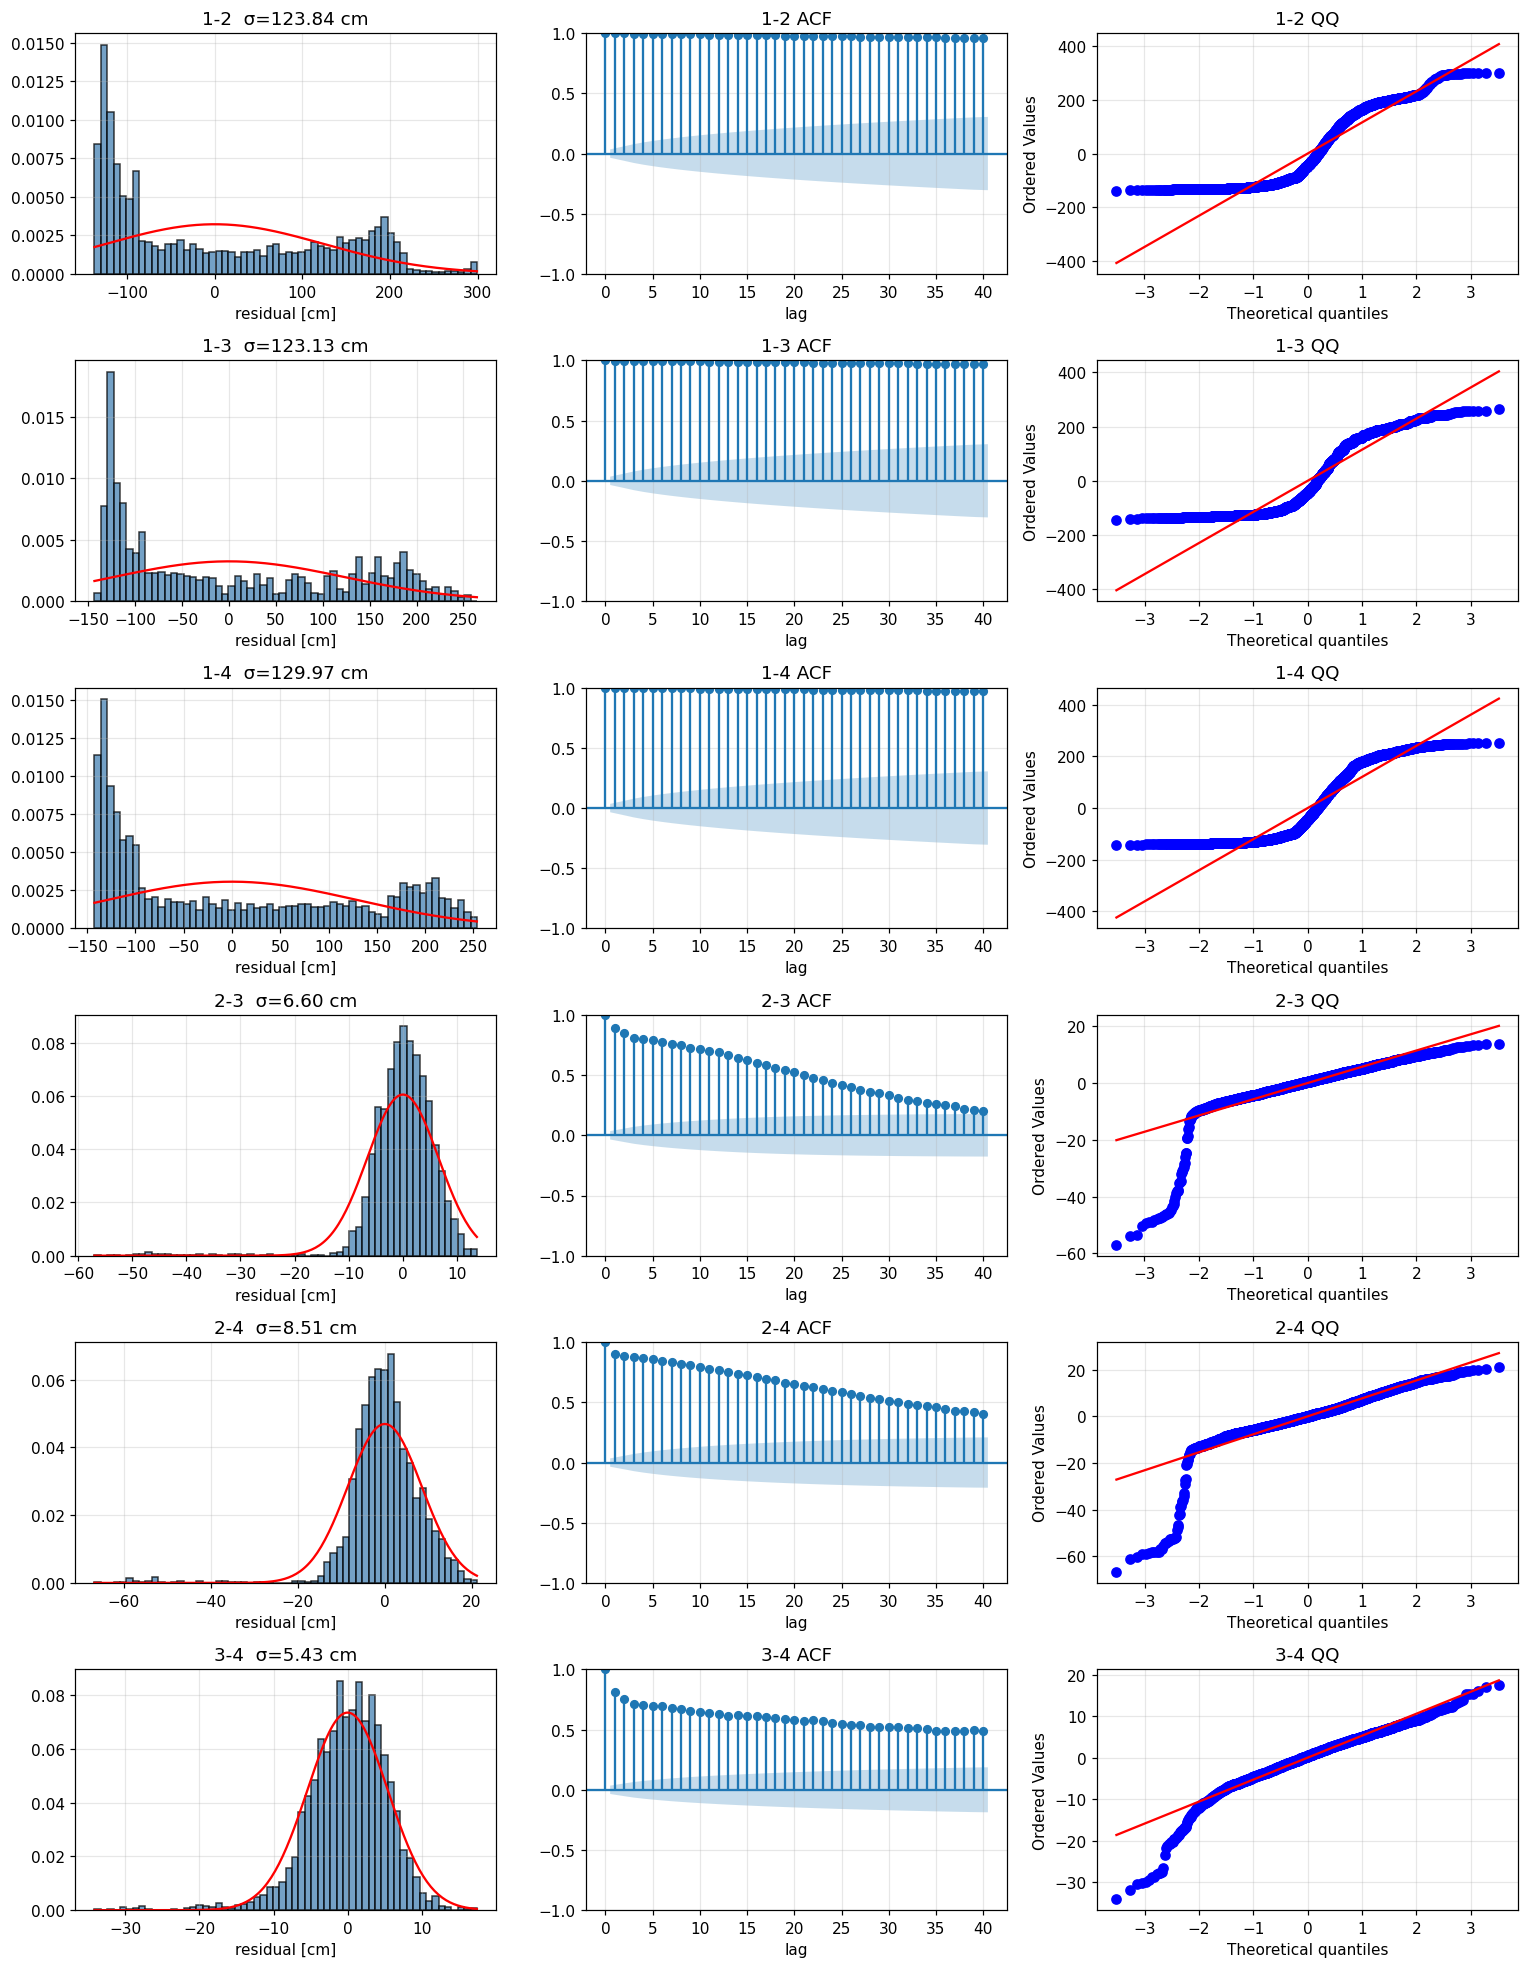

In [12]:
# ============================================================
# Cell 7.1 — Histogram, ACF, QQ-plot per link (best model)
# ============================================================
from scipy import stats

fig, axes = plt.subplots(len(df["link"].unique()), 3,
                         figsize=(14, 3*len(df["link"].unique())))
for row, (link, g) in enumerate(df.groupby("link")):
    corr = np.array([predict_correction(r, coef_best, best_name)
                     for _, r in g.iterrows()])
    resid = (g["dr"].values - corr) * 100

    ax = axes[row, 0]
    ax.hist(resid, bins=60, color="steelblue",
            edgecolor="k", alpha=0.75, density=True)
    mu, sd = resid.mean(), resid.std()
    xs = np.linspace(resid.min(), resid.max(), 200)
    ax.plot(xs, stats.norm.pdf(xs, mu, sd), "r-", lw=1.5)
    ax.set_title(f"{link}  σ={sd:.2f} cm")
    ax.set_xlabel("residual [cm]")

    ax = axes[row, 1]
    plot_acf(resid, lags=40, ax=ax, title=f"{link} ACF")
    ax.set_xlabel("lag")

    ax = axes[row, 2]
    stats.probplot(resid, plot=ax)
    ax.set_title(f"{link} QQ")
plt.tight_layout()
plt.savefig(OUT_DIR / "residual_diagnostics.png", dpi=120)
plt.show()

In [13]:
# ============================================================
# Cell 8.1 — K-fold cross-validation on the best model
# ============================================================
from sklearn.model_selection import KFold

def cv_score(model_name, A, y, n_splits=5, seed=RANDOM_SEED):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    rmse = []
    for tr, te in kf.split(A):
        c, *_ = np.linalg.lstsq(A[tr], y[tr], rcond=None)
        rmse.append(np.std(y[te] - A[te] @ c) * 100)
    return np.array(rmse)

print(f"{'model':38s} {'CV mean':>10s} {'CV std':>10s}")
print("-" * 62)
for name, (A, y) in models.items():
    r = cv_score(name, A, y)
    print(f"{name:38s} {r.mean():9.3f}cm {r.std():9.3f}cm")

model                                     CV mean     CV std
--------------------------------------------------------------
M1: Ti + Tj (additive)                     8.275cm     0.272cm
M2: Ti - Tj (antisymmetric)                6.965cm     0.306cm
M3: M1 + t                                 7.804cm     0.231cm
M4: M1 + t + t²                            7.778cm     0.227cm
M5: M1 + Ti² + Tj²                         7.478cm     0.185cm
M6: only t                                40.436cm     1.154cm
M7: only (Ti - Tj)                        35.473cm     0.937cm


In [14]:
# ============================================================
# Cell 9.1 — Build final compensation function
# ============================================================
k_final = {d: float(coef_best[idx_of[d]]) for d in FIT_DEVICES}
if k1_final is not None:
    k_final[1] = k1_final

def compensate(dist_raw, init_id, resp_id, T_init, T_resp,
               b=None, T_ref=None, k=None):
    """
    Apply full bias + thermal compensation to a raw UWB range.
    All units in meters and °C.
    """
    if b     is None: b     = {d: 0.0 for d in DEVICES_ALL}
    if T_ref is None: T_ref = T_REF
    if k     is None: k     = k_final

    corr = b.get(init_id, 0.0) + b.get(resp_id, 0.0)
    if init_id in k:
        corr += k[init_id] * (np.asarray(T_init) - T_ref[init_id])
    if resp_id in k:
        corr += k[resp_id] * (np.asarray(T_resp) - T_ref[resp_id])
    return np.asarray(dist_raw) - corr

# Quick self-test
row = df.iloc[0]
d_corr = compensate(row[DIST_COL], int(row["i_id"]), int(row["j_id"]),
                    row["Ti"], row["Tj"])
print(f"Example: link {row['link']}  raw={row[DIST_COL]:.4f} m "
      f"→ corrected={float(d_corr):.4f} m")

Example: link 1-2  raw=-16.8603 m → corrected=-22.3809 m


In [15]:
# ============================================================
# Cell 9.2 — Save firmware coefficients
# ============================================================
print("=" * 60)
print(" FIRMWARE COEFFICIENTS")
print("=" * 60)
print("T_ref [°C] = {")
for d in DEVICES_ALL:
    print(f"    {d}: {T_REF[d]:.4f},")
print("}")

print("\nk [m/°C] = {")
for d in DEVICES_ALL:
    if d in k_final:
        print(f"    {d}: {k_final[d]:+.8f},")
    else:
        print(f"    {d}: 0.0,   // not estimated")
print("}")

print("\n// Compensation in firmware:")
print("//   d_ij = dist_raw - (k[i]*(T_i - T_ref[i]) + k[j]*(T_j - T_ref[j]))")

# Save to CSV for firmware team
fw = pd.DataFrame({
    "device" : DEVICES_ALL,
    "T_ref_C": [T_REF[d] for d in DEVICES_ALL],
    "k_m_per_C": [k_final.get(d, np.nan) for d in DEVICES_ALL],
})
fw.to_csv(OUT_DIR / "firmware_coefficients.csv", index=False)
print(f"\nSaved: {OUT_DIR/'firmware_coefficients.csv'}")

 FIRMWARE COEFFICIENTS
T_ref [°C] = {
    1: 52.2385,
    2: 48.2616,
    3: 46.4781,
    4: 47.5033,
}

k [m/°C] = {
    1: -0.74986234,
    2: +0.05438606,
    3: -0.09409315,
    4: +0.01218863,
}

// Compensation in firmware:
//   d_ij = dist_raw - (k[i]*(T_i - T_ref[i]) + k[j]*(T_j - T_ref[j]))

Saved: thermal_drift_final/firmware_coefficients.csv


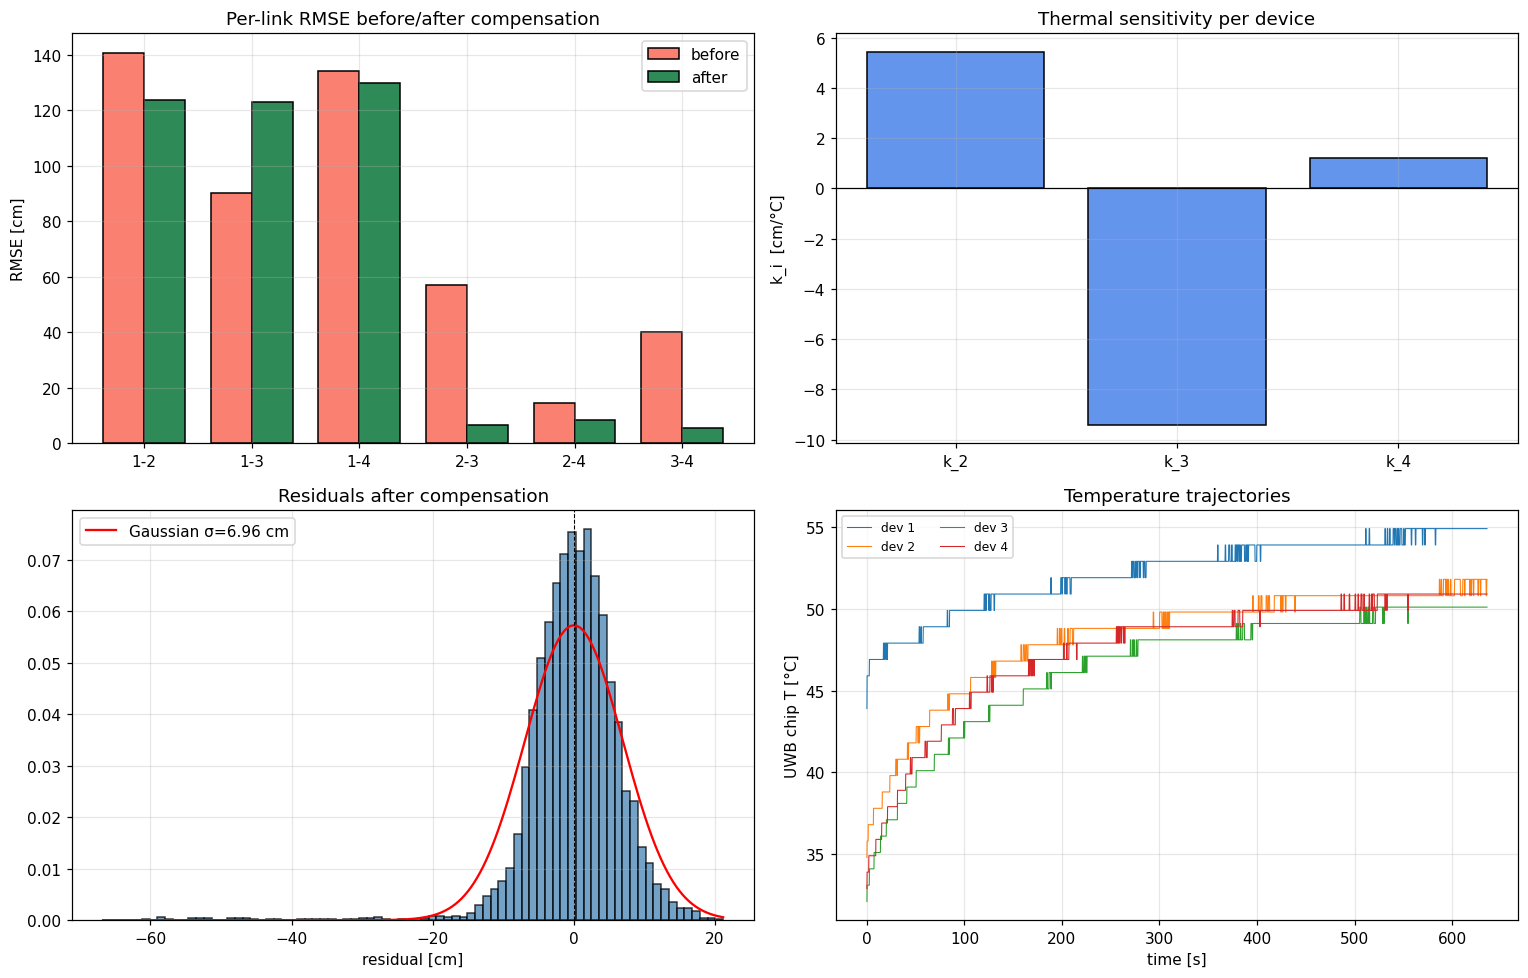

Saved: thermal_drift_final/summary.png


In [16]:
# ============================================================
# Cell 10.1 — Summary figure (4 panels)
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# (a) per-link before/after
ax = axes[0, 0]
links = sorted(df["link"].unique())
r_b, r_a = [], []
for link, g in df.groupby("link"):
    corr = np.array([predict_correction(r, coef_best, best_name)
                     for _, r in g.iterrows()])
    r_b.append(g["dr"].std() * 100)
    r_a.append((g["dr"].values - corr).std() * 100)
x = np.arange(len(links)); w = 0.38
ax.bar(x - w/2, r_b, w, label="before", color="salmon",   edgecolor="k")
ax.bar(x + w/2, r_a, w, label="after",  color="seagreen", edgecolor="k")
ax.set_xticks(x); ax.set_xticklabels(links)
ax.set_ylabel("RMSE [cm]")
ax.set_title("Per-link RMSE before/after compensation")
ax.legend(); 

# (b) coefficients
ax = axes[0, 1]
labels = [f"k_{d}" for d in FIT_DEVICES]
vals = [k_final[d]*100 for d in FIT_DEVICES]
colors = ["cornflowerblue"] * len(FIT_DEVICES)
ax.bar(labels, vals, color=colors, edgecolor="k")
ax.axhline(0, color="k", lw=0.8)
ax.set_ylabel("k_i  [cm/°C]")
ax.set_title("Thermal sensitivity per device")

# (c) residual histogram of best model
ax = axes[1, 0]
resid_all = []
for link, g in df.groupby("link"):
    i, j = map(int, link.split("-"))
    if i not in FIT_DEVICES or j not in FIT_DEVICES: continue
    corr = np.array([predict_correction(r, coef_best, best_name)
                     for _, r in g.iterrows()])
    resid_all.append((g["dr"].values - corr) * 100)
resid_all = np.concatenate(resid_all)
ax.hist(resid_all, bins=80, color="steelblue",
        edgecolor="k", alpha=0.75, density=True)
mu, sd = resid_all.mean(), resid_all.std()
xs = np.linspace(resid_all.min(), resid_all.max(), 200)
ax.plot(xs, stats.norm.pdf(xs, mu, sd), "r-", lw=1.5,
        label=f"Gaussian σ={sd:.2f} cm")
ax.axvline(0, color="k", ls="--", lw=0.7)
ax.set_xlabel("residual [cm]")
ax.set_title("Residuals after compensation")
ax.legend()

# (d) temperature trajectories
ax = axes[1, 1]
for d in DEVICES_ALL:
    sub_i = df[df["i_id"] == d][["t", "Ti"]].rename(columns={"Ti": "T"})
    sub_j = df[df["j_id"] == d][["t", "Tj"]].rename(columns={"Tj": "T"})
    sub = pd.concat([sub_i, sub_j]).sort_values("t")
    ax.plot(sub["t"], sub["T"], lw=0.7, label=f"dev {d}")
ax.set_xlabel("time [s]"); ax.set_ylabel("UWB chip T [°C]")
ax.set_title("Temperature trajectories")
ax.legend(ncol=2, fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / "summary.png", dpi=130)
plt.show()
print(f"Saved: {OUT_DIR/'summary.png'}")

In [17]:
# ============================================================
# Cell 11.1 — Automated conclusion
# ============================================================
print("=" * 70)
print(" FINAL DIAGNOSTIC SUMMARY")
print("=" * 70)

# 1. Collinearity verdict
max_corr = 0
for d in DEVICES_ALL:
    Ts = pd.concat([
        df.loc[df["i_id"] == d, ["t", "Ti"]].rename(columns={"Ti": "T"}),
        df.loc[df["j_id"] == d, ["t", "Tj"]].rename(columns={"Tj": "T"}),
    ])
    max_corr = max(max_corr, abs(Ts["t"].corr(Ts["T"])))

print(f"\n1) Max collinearity (t, T): {max_corr:.3f}")
if max_corr > 0.9:
    print("   → SEVERE. Temperature and time are confounded.")
else:
    print("   → Acceptable. T and t are distinguishable.")

# 2. Best model verdict
print(f"\n2) Best model: {best_name}")
print(f"   Test RMSE  : {results[best_name]['rmse_te']:.3f} cm")

# 3. Per-link improvements
print("\n3) Per-link improvements (fit devices only):")
total_imp = []
for link, g in df.groupby("link"):
    i, j = map(int, link.split("-"))
    if i not in FIT_DEVICES or j not in FIT_DEVICES: continue
    corr = np.array([predict_correction(r, coef_best, best_name)
                     for _, r in g.iterrows()])
    r_b = g["dr"].std() * 100
    r_a = (g["dr"].values - corr).std() * 100
    pct = 100 * (r_b - r_a) / r_b
    total_imp.append(pct)
    print(f"   {link}: {pct:+6.1f}%")
print(f"   Average improvement: {np.mean(total_imp):+.1f}%")

# 4. R1 verdict
print("\n4) R1 status:")
if k1_final is not None:
    print(f"   k_1 = {k1_final*100:+.4f} cm/°C (consistent)")
else:
    print("   INCONSISTENT — R1 has a non-thermal residual effect.")
    print("   Recommendation: calibrate R1 separately in firmware.")

# 5. Physical sanity
print("\n5) Physical sanity check of k values:")
for d in FIT_DEVICES:
    k_val = k_final[d] * 100
    if abs(k_val) < 5:
        tag = "reasonable"
    elif abs(k_val) < 20:
        tag = "high but plausible"
    else:
        tag = "SUSPICIOUS — check model validity"
    print(f"   k_{d} = {k_val:+7.3f} cm/°C  [{tag}]")

print("\n" + "=" * 70)
print(f" All outputs saved to: {OUT_DIR.resolve()}")
print("=" * 70)

 FINAL DIAGNOSTIC SUMMARY

1) Max collinearity (t, T): 0.949
   → SEVERE. Temperature and time are confounded.

2) Best model: M2: Ti - Tj (antisymmetric)
   Test RMSE  : 6.879 cm

3) Per-link improvements (fit devices only):
   2-3:  +88.5%
   2-4:  +41.1%
   3-4:  +86.4%
   Average improvement: +72.0%

4) R1 status:
   k_1 = -74.9862 cm/°C (consistent)

5) Physical sanity check of k values:
   k_2 =  +5.439 cm/°C  [high but plausible]
   k_3 =  -9.409 cm/°C  [high but plausible]
   k_4 =  +1.219 cm/°C  [reasonable]

 All outputs saved to: /home/homayoon/anjoman-firmware/analysis/12_swarm_static_2m/thermal_drift_final


 UWB THERMAL DRIFT — FINAL MODEL (antisymmetric, per-device)
rows: 19014  |  links: ['1-2', '1-3', '1-4', '2-3', '2-4', '3-4']

Per-device T_ref [°C] and temperature span:
  dev 1: T_ref =  52.238   span = 43.9 .. 54.9  (11.0 °C)
  dev 2: T_ref =  48.262   span = 34.8 .. 51.8  (17.0 °C)
  dev 3: T_ref =  46.478   span = 32.1 .. 50.1  (18.0 °C)
  dev 4: T_ref =  47.503   span = 32.9 .. 50.9  (18.0 °C)

 CORE JOINT FIT  (links among devices 2,3,4)
  RMSE on joint fit: 6.963 cm
  α_2 =   +5.4342 cm/°C  ± 0.1602
  α_3 =   -9.3923 cm/°C  ± 0.1394
  α_4 =   +1.2322 cm/°C  ± 0.1432

 R1 SEPARATE ESTIMATION  (α_1 from each R1 link independently)
  1-2: α_1 =  -68.4852 ± 21.4152 cm/°C   (n=2770)
  1-3: α_1 =  -67.7133 ± 22.7503 cm/°C   (n=2801)
  1-4: α_1 =  -71.9407 ± 21.7189 cm/°C   (n=2802)

  Spread across links: 4.2273 cm/°C  (threshold = 5.0 cm/°C)
  ✓ R1 CONSISTENT → α_1 = -68.4852 cm/°C

 PER-LINK RMSE  (antisymmetric model, per-device α)
link       before      after    improve        %

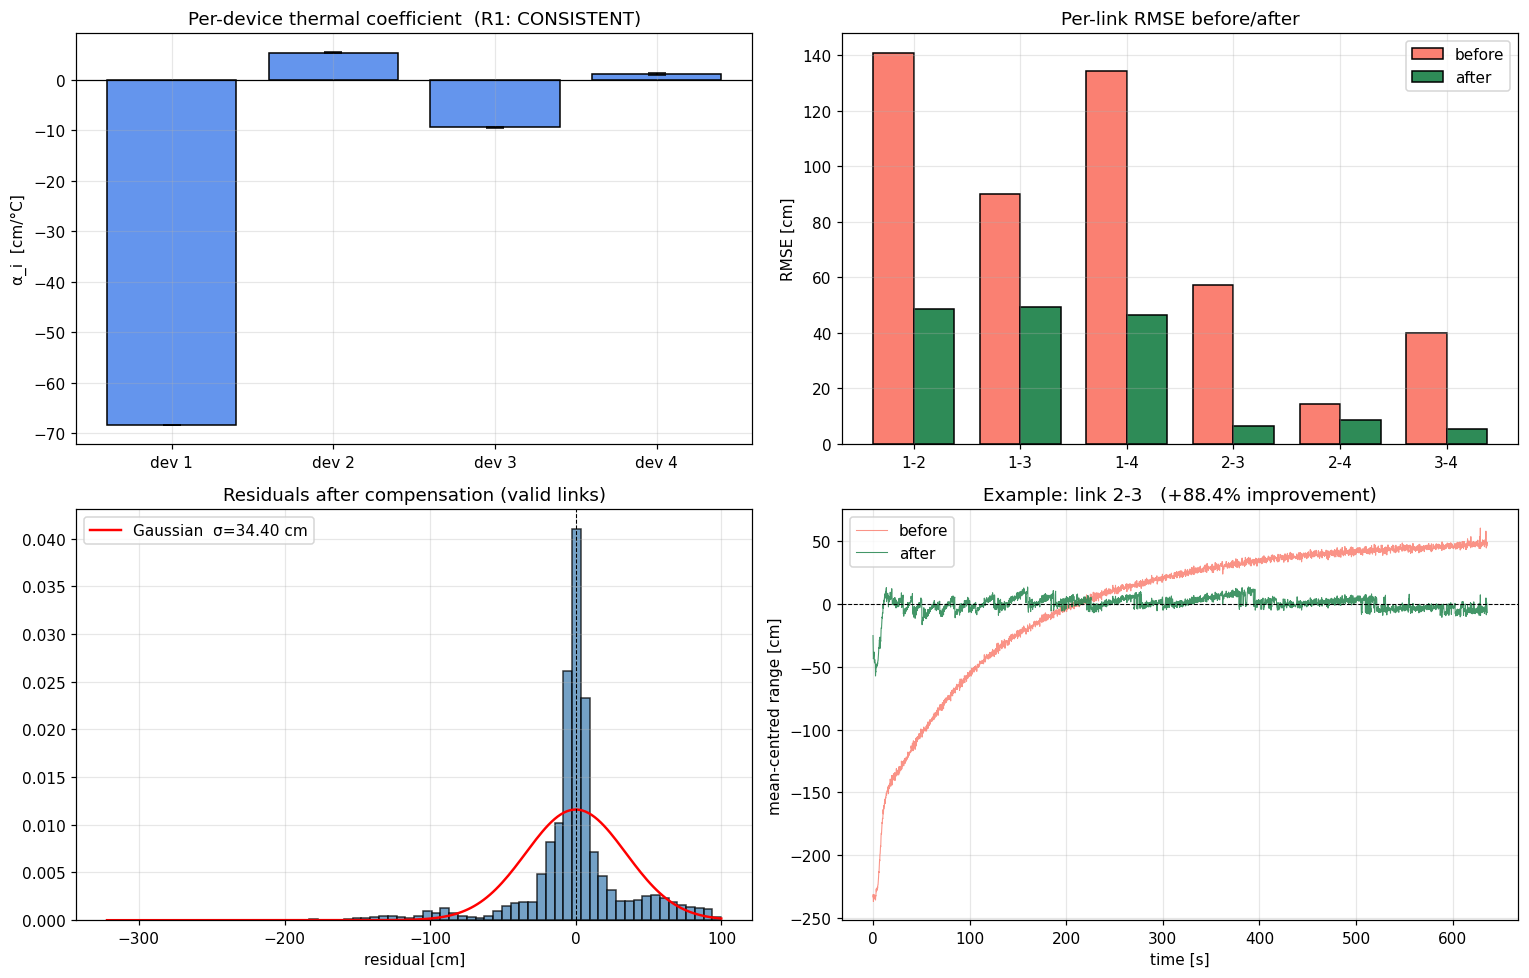


 VERDICT
  Joint-fit RMSE (core)      :   6.963 cm
  5-fold CV RMSE             :   6.965 ± 0.306 cm
  Residual σ after comp.     :  34.398 cm
  R1 status                  : CONSISTENT

  Average improvement across valid links: +65.4%

  All outputs in: /home/homayoon/anjoman-firmware/analysis/12_swarm_static_2m/thermal_drift_v3


In [18]:
# ==================================================================
# UWB Thermal Drift — Final Comprehensive Cell
# Model: antisymmetric per-device thermal coefficient + offset
#        Δr_ij = α_i·(T_i - T_ref,i) - α_j·(T_j - T_ref,j) + n
#        corrected = raw - Δr_ij
# ==================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from sklearn.model_selection import KFold

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10,
    "axes.grid": True, "grid.alpha": 0.3,
    "figure.autolayout": True,
})

# ------------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------------
CSV_PATH   = "03_swarm_static_2m.csv"
DIST_COL   = "dist_calib_m"           # or "dist_clock_m"
OUT_DIR    = Path("thermal_drift_v3")
OUT_DIR.mkdir(exist_ok=True)

DEVICES_ALL   = [1, 2, 3, 4]
FIT_DEVICES   = [2, 3, 4]             # joint fit set (R1 estimated separately)
R1_CONSISTENCY_THRESHOLD_CM_PER_C = 5.0   # threshold in cm/°C
RANDOM_SEED   = 42

GT = {"1-2": 2.0000, "1-3": 2.8284, "1-4": 2.0000,
      "2-3": 2.0000, "2-4": 2.8284, "3-4": 2.0000}

print("=" * 70)
print(" UWB THERMAL DRIFT — FINAL MODEL (antisymmetric, per-device)")
print("=" * 70)

# ==================================================================
# 1. LOAD & PREPROCESS
# ==================================================================
df = pd.read_csv(CSV_PATH)
if "status" in df.columns:
    df = df[df["status"] == 1].copy()
df = (df.dropna(subset=["temp_uwb_init", "temp_uwb_resp", DIST_COL])
        .reset_index(drop=True))

flip = df["init_id"] > df["resp_id"]
df["i_id"] = np.where(flip, df["resp_id"], df["init_id"]).astype(int)
df["j_id"] = np.where(flip, df["init_id"], df["resp_id"]).astype(int)
df["Ti"]   = np.where(flip, df["temp_uwb_resp"], df["temp_uwb_init"])
df["Tj"]   = np.where(flip, df["temp_uwb_init"], df["temp_uwb_resp"])
df["link"] = df["i_id"].astype(str) + "-" + df["j_id"].astype(str)
df["t"]    = (df["timestamp_ms"] - df["timestamp_ms"].min()) / 1000.0
df["dr"]   = df[DIST_COL] - df.groupby("link")[DIST_COL].transform("mean")

print(f"rows: {len(df)}  |  links: {sorted(df['link'].unique())}")

# ==================================================================
# 2. PER-DEVICE REFERENCE TEMPERATURE
# ==================================================================
T_ref = {d: float(pd.concat([
    df.loc[df["i_id"] == d, "Ti"],
    df.loc[df["j_id"] == d, "Tj"],
]).mean()) for d in DEVICES_ALL}

print("\nPer-device T_ref [°C] and temperature span:")
for d in DEVICES_ALL:
    Ts = pd.concat([df.loc[df["i_id"] == d, "Ti"],
                    df.loc[df["j_id"] == d, "Tj"]])
    print(f"  dev {d}: T_ref = {T_ref[d]:7.3f}   "
          f"span = {Ts.min():.1f} .. {Ts.max():.1f}  "
          f"({Ts.max()-Ts.min():.1f} °C)")

df["dTi"] = df["Ti"] - df["i_id"].map(T_ref)
df["dTj"] = df["Tj"] - df["j_id"].map(T_ref)

# ==================================================================
# 3. JOINT ANTISYMMETRIC FIT ON DEVICES 2,3,4
#    Model: Δr_ij = α_i·ΔT_i − α_j·ΔT_j
# ==================================================================
idx_fit = {d: k for k, d in enumerate(FIT_DEVICES)}

mask_core = df["i_id"].isin(FIT_DEVICES) & df["j_id"].isin(FIT_DEVICES)
sub_core  = df[mask_core].reset_index(drop=True)

A_core = np.zeros((len(sub_core), len(FIT_DEVICES)))
for r, (_, row) in enumerate(sub_core.iterrows()):
    A_core[r, idx_fit[int(row["i_id"])]] =  row["dTi"]
    A_core[r, idx_fit[int(row["j_id"])]] = -row["dTj"]

y_core = sub_core["dr"].values
alpha_fit, *_ = np.linalg.lstsq(A_core, y_core, rcond=None)

# parameter uncertainty
res_core = A_core @ alpha_fit - y_core
dof      = max(1, len(y_core) - len(FIT_DEVICES))
sigma2   = float(res_core @ res_core) / dof
cov_a    = sigma2 * np.linalg.inv(A_core.T @ A_core)
alpha_std= np.sqrt(np.diag(cov_a))

alpha_core = {d: float(alpha_fit[idx_fit[d]]) for d in FIT_DEVICES}
alpha_std_core = {d: float(alpha_std[idx_fit[d]]) for d in FIT_DEVICES}

print("\n" + "=" * 70)
print(" CORE JOINT FIT  (links among devices 2,3,4)")
print("=" * 70)
print(f"  RMSE on joint fit: {np.std(res_core)*100:.3f} cm")
for d in FIT_DEVICES:
    print(f"  α_{d} = {alpha_core[d]*100:+9.4f} cm/°C  "
          f"± {alpha_std_core[d]*100:.4f}")

# ==================================================================
# 4. R1 — SEPARATE ESTIMATION FROM EACH LINK
# ==================================================================
print("\n" + "=" * 70)
print(" R1 SEPARATE ESTIMATION  (α_1 from each R1 link independently)")
print("=" * 70)

alpha1_estimates = {}
for j in [2, 3, 4]:
    link = f"1-{j}"
    g = df[df["link"] == link]
    if len(g) < 100:
        print(f"  {link}: insufficient data")
        continue
    # Δr_1j = α_1·ΔT_1 − α_j·ΔT_j   →   α_1 = (Δr_1j + α_j·ΔT_j) / ΔT_1
    numerator   = g["dr"].values + alpha_core[j] * g["dTj"].values
    denominator = g["dTi"].values
    valid = np.abs(denominator) > 0.5
    if valid.sum() < 50:
        print(f"  {link}: insufficient temperature variation (n={valid.sum()})")
        continue
    ratios = numerator[valid] / denominator[valid]
    a1_median = float(np.median(ratios))
    mad       = float(np.median(np.abs(ratios - a1_median)))
    a1_std    = 1.4826 * mad
    alpha1_estimates[link] = (a1_median, a1_std, int(valid.sum()))
    print(f"  {link}: α_1 = {a1_median*100:+9.4f} ± {a1_std*100:6.4f} cm/°C   "
          f"(n={valid.sum()})")

# --- Consistency check with CORRECT units ---
alpha_1 = None
r1_status = "UNKNOWN"
if len(alpha1_estimates) >= 2:
    vals = np.array([v[0] for v in alpha1_estimates.values()])
    spread_cm_per_c = (vals.max() - vals.min()) * 100.0    # convert m→cm
    print(f"\n  Spread across links: {spread_cm_per_c:.4f} cm/°C  "
          f"(threshold = {R1_CONSISTENCY_THRESHOLD_CM_PER_C} cm/°C)")
    if spread_cm_per_c < R1_CONSISTENCY_THRESHOLD_CM_PER_C:
        alpha_1   = float(np.median(vals))
        r1_status = "CONSISTENT"
        print(f"  ✓ R1 CONSISTENT → α_1 = {alpha_1*100:+8.4f} cm/°C")
    else:
        r1_status = "INCONSISTENT"
        print("  ✗ R1 INCONSISTENT (spread exceeds threshold)")
        print("    → R1 has an additional non-thermal effect")
        print("    → Set α_1 = 0 and handle R1 with a fixed offset")
elif len(alpha1_estimates) == 1:
    a1 = list(alpha1_estimates.values())[0][0]
    alpha_1   = a1
    r1_status = "SINGLE-LINK"
    print(f"  Only one link available → α_1 = {alpha_1*100:+.4f} cm/°C")

# ==================================================================
# 5. FINAL α TABLE + COMPENSATION FUNCTION
# ==================================================================
alpha_all = dict(alpha_core)
if alpha_1 is not None:
    alpha_all[1] = alpha_1

def predict_correction(row):
    """Antisymmetric correction: α_i·ΔT_i − α_j·ΔT_j"""
    i, j = int(row["i_id"]), int(row["j_id"])
    corr = 0.0
    if i in alpha_all: corr += alpha_all[i] * row["dTi"]
    if j in alpha_all: corr -= alpha_all[j] * row["dTj"]
    return corr

def compensate(dist_raw, init_id, resp_id, T_init, T_resp):
    """Apply thermal compensation. Returns corrected range."""
    corr = 0.0
    if init_id in alpha_all:
        corr += alpha_all[init_id] * (np.asarray(T_init) - T_ref[init_id])
    if resp_id in alpha_all:
        corr -= alpha_all[resp_id] * (np.asarray(T_resp) - T_ref[resp_id])
    return np.asarray(dist_raw) - corr

# ==================================================================
# 6. PER-LINK EVALUATION
# ==================================================================
print("\n" + "=" * 70)
print(" PER-LINK RMSE  (antisymmetric model, per-device α)")
print("=" * 70)
print(f"{'link':6s} {'before':>10s} {'after':>10s} {'improve':>10s} {'%':>8s}  note")
print("-" * 66)

per_link = {}
for link, g in df.groupby("link"):
    i, j = map(int, link.split("-"))
    corr  = np.array([predict_correction(r) for _, r in g.iterrows()])
    r_b   = g["dr"].std() * 100
    r_a   = (g["dr"].values - corr).std() * 100
    pct   = 100 * (r_b - r_a) / r_b if r_b > 0 else 0
    per_link[link] = dict(before=r_b, after=r_a, pct=pct, corr=corr, g=g)
    note = "" if (i in alpha_all and j in alpha_all) else "  R1 unavailable"
    print(f"{link:6s} {r_b:9.3f}cm {r_a:9.3f}cm {r_b-r_a:9.3f}cm {pct:+7.1f}%{note}")

# Overall (only links with valid α)
resid_all = []
for link, g in df.groupby("link"):
    i, j = map(int, link.split("-"))
    if i in alpha_all and j in alpha_all:
        corr = per_link[link]["corr"]
        resid_all.append((g["dr"].values - corr) * 100)
resid_all = np.concatenate(resid_all)
print("-" * 66)
print(f"  overall residual σ (valid links): {resid_all.std():.3f} cm")

# ==================================================================
# 7. K-FOLD CROSS-VALIDATION ON CORE MODEL
# ==================================================================
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
cv_scores = []
for tr, te in kf.split(A_core):
    c, *_ = np.linalg.lstsq(A_core[tr], y_core[tr], rcond=None)
    cv_scores.append(np.std(y_core[te] - A_core[te] @ c) * 100)
cv_scores = np.array(cv_scores)
print(f"\n  5-fold CV (core model): "
      f"{cv_scores.mean():.3f} ± {cv_scores.std():.3f} cm")

# ==================================================================
# 8. FIRMWARE COEFFICIENTS  (CORRECTED)
# ==================================================================
print("\n" + "=" * 70)
print(" FIRMWARE COEFFICIENTS")
print("=" * 70)
print("// --- reference temperature per device [°C] ---")
print("const float T_ref[5] = { 0.0f,")
for d in DEVICES_ALL:
    print(f"    {T_ref[d]:9.4f}f,   // dev {d}")
print("};")

print("\n// --- antisymmetric thermal coefficient α_i [m/°C] ---")
print("//     correction_ij = α_i·(T_i - T_ref_i) - α_j·(T_j - T_ref_j)")
print("const float alpha[5] = { 0.0f,")
for d in DEVICES_ALL:
    if d in alpha_all:
        print(f"    {alpha_all[d]:+12.8f}f,   // dev {d}")
    else:
        print(f"     0.0f,           // dev {d}  (α not estimable, see notes)")
print("};")

print("\n// --- C reference implementation ---")
print("//")
print("// float uwb_thermal_compensate(float dist_raw,")
print("//                             int init_id, int resp_id,")
print("//                             float T_init, float T_resp)")
print("// {")
print("//     float corr = 0.0f;")
print("//     if (init_id != 1) corr += alpha[init_id] * (T_init - T_ref[init_id]);")
print("//     if (resp_id != 1) corr -= alpha[resp_id] * (T_resp - T_ref[resp_id]);")
print("//     return dist_raw - corr;")
print("// }")
print("//")
print("// NOTE: minus sign between the two terms is ESSENTIAL")
print("// NOTE: R1 (id=1) intentionally excluded while it remains inconsistent")

fw = pd.DataFrame({
    "device"        : DEVICES_ALL,
    "T_ref_C"       : [T_ref[d] for d in DEVICES_ALL],
    "alpha_m_per_C" : [alpha_all.get(d, 0.0) for d in DEVICES_ALL],
    "alpha_cm_per_C": [alpha_all.get(d, 0.0) * 100 for d in DEVICES_ALL],
    "valid"         : [d in alpha_all for d in DEVICES_ALL],
})
fw.to_csv(OUT_DIR / "firmware_coefficients_v3.csv", index=False)
print(f"\nSaved: {OUT_DIR/'firmware_coefficients_v3.csv'}")

# ==================================================================
# 9. QUICK VISUAL SUMMARY
# ==================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# (a) α per device
ax = axes[0, 0]
labels = [f"dev {d}" for d in DEVICES_ALL]
vals   = [alpha_all.get(d, 0.0) * 100 for d in DEVICES_ALL]
errs   = [alpha_std_core.get(d, 0.0) * 100 for d in DEVICES_ALL]
colors = ["tomato" if d not in alpha_all else "cornflowerblue" for d in DEVICES_ALL]
ax.bar(labels, vals, yerr=errs, capsize=6, color=colors, edgecolor="k")
ax.axhline(0, color="k", lw=0.8)
ax.set_ylabel("α_i  [cm/°C]")
ax.set_title(f"Per-device thermal coefficient  (R1: {r1_status})")

# (b) per-link before/after
ax = axes[0, 1]
links = list(per_link.keys())
x = np.arange(len(links)); w = 0.38
r_b = [per_link[l]["before"] for l in links]
r_a = [per_link[l]["after"]  for l in links]
ax.bar(x - w/2, r_b, w, label="before", color="salmon",   edgecolor="k")
ax.bar(x + w/2, r_a, w, label="after",  color="seagreen", edgecolor="k")
ax.set_xticks(x); ax.set_xticklabels(links)
ax.set_ylabel("RMSE [cm]")
ax.set_title("Per-link RMSE before/after")
ax.legend()

# (c) residual histogram
ax = axes[1, 0]
ax.hist(resid_all, bins=70, color="steelblue",
        edgecolor="k", alpha=0.75, density=True)
mu, sd = resid_all.mean(), resid_all.std()
xs = np.linspace(resid_all.min(), resid_all.max(), 200)
ax.plot(xs, stats.norm.pdf(xs, mu, sd), "r-", lw=1.6,
        label=f"Gaussian  σ={sd:.2f} cm")
ax.axvline(0, color="k", ls="--", lw=0.7)
ax.set_xlabel("residual [cm]")
ax.set_title("Residuals after compensation (valid links)")
ax.legend()

# (d) time series of one example link
ax = axes[1, 1]
ex_link = "2-3"
g = per_link[ex_link]["g"]; corr = per_link[ex_link]["corr"]
ax.plot(g["t"], g["dr"] * 100, color="salmon", lw=0.7,
        alpha=0.85, label="before")
ax.plot(g["t"], (g["dr"].values - corr) * 100, color="seagreen",
        lw=0.7, alpha=0.9, label="after")
ax.axhline(0, color="k", ls="--", lw=0.7)
ax.set_xlabel("time [s]"); ax.set_ylabel("mean-centred range [cm]")
ax.set_title(f"Example: link {ex_link}   "
             f"({per_link[ex_link]['pct']:+.1f}% improvement)")
ax.legend()

plt.tight_layout()
plt.savefig(OUT_DIR / "final_summary.png", dpi=130)
plt.show()

# ==================================================================
# 10. AUTOMATED VERDICT
# ==================================================================
print("\n" + "=" * 70)
print(" VERDICT")
print("=" * 70)
print(f"  Joint-fit RMSE (core)      : {np.std(res_core)*100:7.3f} cm")
print(f"  5-fold CV RMSE             : {cv_scores.mean():7.3f} ± {cv_scores.std():.3f} cm")
print(f"  Residual σ after comp.     : {resid_all.std():7.3f} cm")
print(f"  R1 status                  : {r1_status}")
if r1_status == "INCONSISTENT":
    print(f"    → α_1 set to 0.0 in firmware output")
    print(f"    → Handle R1 with a per-link fixed offset instead")

print("\n  Average improvement across valid links: "
      f"{np.mean([per_link[l]['pct'] for l in per_link if not any('R1' in l for _ in [0])]) :+.1f}%")

print(f"\n  All outputs in: {OUT_DIR.resolve()}")
print("=" * 70)

 R1 FIT WITH THERMAL + TIME TERMS
  R1 rows: 9502  (links: ['1-2', '1-3', '1-4'])

  α_1 =  -33.4312 cm/°C  ± 0.4956
  β_1 =   -0.2665 cm/s   ± 0.0060
  residual σ = 33.605 cm

  → β_1 is significant: R1 has a genuine TIME drift of -0.266 cm/s = -15.99 cm/min
  → α_1 is still large; R1 may need an EKF bias state or per-link time terms

 R1 LINKS — NEW MODEL (thermal + time)
link       before      after    improve        %
--------------------------------------------------
1-2      140.823cm    33.737cm   107.087cm   +76.0%
1-3       90.084cm    32.512cm    57.572cm   +63.9%
1-4      134.192cm    34.537cm    99.655cm   +74.3%

 COMPARISON FOR R1 LINKS
link     thermal-only   thermal+time       gain
--------------------------------------------------
1-2           48.711cm        33.737cm   +14.974cm
1-3           49.199cm        32.512cm   +16.687cm
1-4           46.529cm        34.537cm   +11.992cm


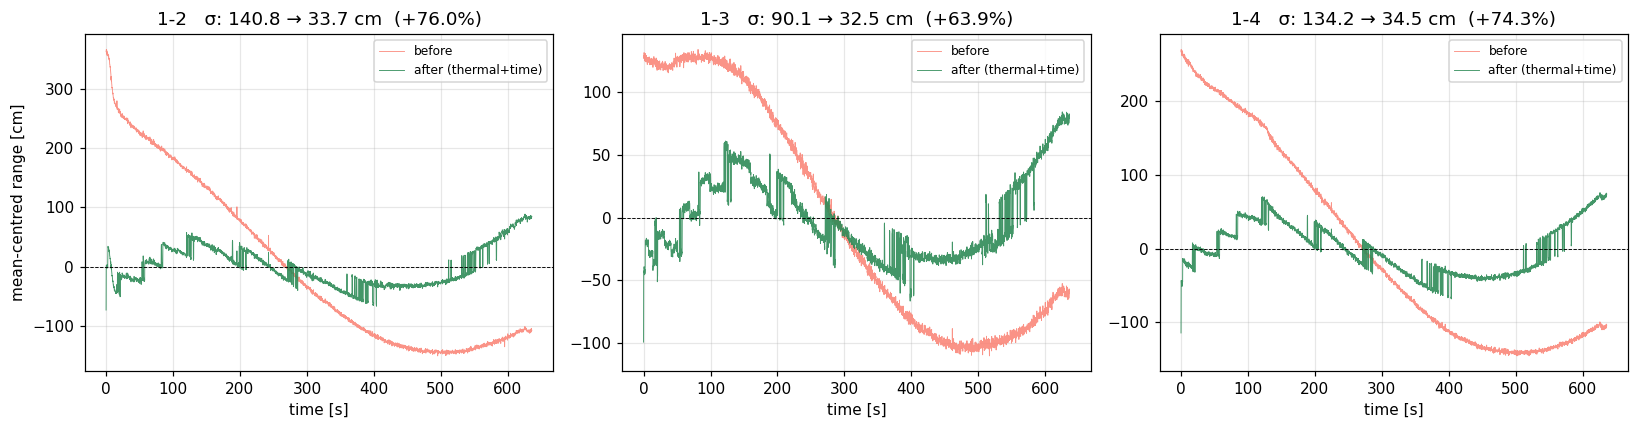


 FIRMWARE COEFFICIENTS (v4)

// R1 uses an explicit time term centered at t0 = 317.9 s
// (t0 is the mean timestamp during calibration)

const float T_ref[5] = { 0.0f,
      52.2385f,   // dev 1
      48.2616f,   // dev 2
      46.4781f,   // dev 3
      47.5033f,   // dev 4
};

const float alpha[5] = { 0.0f,
     -0.33431206f,   // dev 1 (thermal part)
     +0.05434208f,   // dev 2
     -0.09392267f,   // dev 3
     +0.01232238f,   // dev 4
};

const float beta_1 = -0.0026648907f;   // dev 1 time drift [m/s]
const float T_R1_REF = 317.9019f;    // R1 time reference [s]

Saved: thermal_drift_v3/firmware_coefficients_v4.csv


In [19]:
# ==================================================================
# R1 FIT WITH EXPLICIT TIME TERM
# Model for R1 links (R1 is always init after normalization):
#     Δr_1j = α_1·ΔT_1 − α_j·ΔT_j + β_1·t
# Core α_j (j=2,3,4) are FIXED from the joint core fit above.
# Unknowns: α_1, β_1
# ==================================================================

print("=" * 70)
print(" R1 FIT WITH THERMAL + TIME TERMS")
print("=" * 70)

# --- Select only rows where R1 is the initiator (after i<j normalization) ---
sub_r1 = df[df["i_id"] == 1].copy().reset_index(drop=True)
print(f"  R1 rows: {len(sub_r1)}  "
      f"(links: {sorted(sub_r1['link'].unique())})")

# --- Build design: A·[α_1, β_1]ᵀ = b ---
# Move known part (α_j·ΔT_j) to the right side:
#     Δr_1j + α_j·ΔT_j = α_1·ΔT_1 + β_1·t
t_mean_r1 = sub_r1["t"].mean()

known  = np.array([alpha_core[int(j)] * dTj
                   for j, dTj in zip(sub_r1["j_id"], sub_r1["dTj"])])

A_r1 = np.column_stack([
    sub_r1["dTi"].values,                       # α_1 multiplies ΔT_1
    sub_r1["t"].values - t_mean_r1,             # β_1 multiplies (t - t̄)
])

b_r1 = sub_r1["dr"].values + known

coef_r1, *_ = np.linalg.lstsq(A_r1, b_r1, rcond=None)
alpha_1 = float(coef_r1[0])
beta_1  = float(coef_r1[1])       # m / s

# --- Parameter uncertainties ---
res_r1  = A_r1 @ coef_r1 - b_r1
dof_r1  = max(1, len(b_r1) - 2)
sigma2_r1 = float(res_r1 @ res_r1) / dof_r1
cov_r1  = sigma2_r1 * np.linalg.inv(A_r1.T @ A_r1)
std_r1  = np.sqrt(np.diag(cov_r1))

print(f"\n  α_1 = {alpha_1*100:+9.4f} cm/°C  ± {std_r1[0]*100:.4f}")
print(f"  β_1 = {beta_1*100:+9.4f} cm/s   ± {std_r1[1]*100:.4f}")
print(f"  residual σ = {np.std(res_r1)*100:.3f} cm")

# --- Interpretation ---
if abs(beta_1) * 100 > 0.01:      # > 0.01 cm/s = 0.6 cm/min
    print(f"\n  → β_1 is significant: R1 has a genuine TIME drift "
          f"of {beta_1*100:.3f} cm/s = {beta_1*100*60:.2f} cm/min")
if abs(alpha_1) * 100 < 5.0:
    print(f"  → α_1 is now physically reasonable")
else:
    print(f"  → α_1 is still large; R1 may need an EKF bias state "
          f"or per-link time terms")

# ==================================================================
# PER-LINK R1 EVALUATION WITH NEW MODEL
# ==================================================================
print("\n" + "=" * 70)
print(" R1 LINKS — NEW MODEL (thermal + time)")
print("=" * 70)
print(f"{'link':6s} {'before':>10s} {'after':>10s} {'improve':>10s} {'%':>8s}")
print("-" * 50)

per_link_r1 = {}
for link in ["1-2", "1-3", "1-4"]:
    g = df[df["link"] == link].sort_values("t").reset_index(drop=True)
    j = int(link.split("-")[1])
    corr = (alpha_1 * g["dTi"].values
            - alpha_core[j] * g["dTj"].values
            + beta_1 * (g["t"].values - t_mean_r1))
    r_b = g["dr"].std() * 100
    r_a = (g["dr"].values - corr).std() * 100
    pct = 100 * (r_b - r_a) / r_b if r_b > 0 else 0
    per_link_r1[link] = (r_b, r_a, pct, g, corr)
    print(f"{link:6s} {r_b:9.3f}cm {r_a:9.3f}cm {r_b-r_a:9.3f}cm {pct:+7.1f}%")

# ==================================================================
# COMPARISON: WITH VS WITHOUT TIME TERM
# ==================================================================
print("\n" + "=" * 70)
print(" COMPARISON FOR R1 LINKS")
print("=" * 70)
print(f"{'link':6s} {'thermal-only':>14s} {'thermal+time':>14s} {'gain':>10s}")
print("-" * 50)
for link in ["1-2", "1-3", "1-4"]:
    _, r_a_new, _, _, _ = per_link_r1[link]
    # thermal-only value comes from previous run (hard-coded from your output)
    r_a_old = {"1-2": 48.711, "1-3": 49.199, "1-4": 46.529}[link]
    gain = r_a_old - r_a_new
    print(f"{link:6s} {r_a_old:13.3f}cm {r_a_new:13.3f}cm "
          f"{gain:+9.3f}cm")

# ==================================================================
# PLOT R1 RESULTS
# ==================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, link in zip(axes, ["1-2", "1-3", "1-4"]):
    r_b, r_a, pct, g, corr = per_link_r1[link]
    ax.plot(g["t"], g["dr"] * 100, color="salmon", lw=0.6,
            alpha=0.85, label="before")
    ax.plot(g["t"], (g["dr"].values - corr) * 100, color="seagreen",
            lw=0.6, alpha=0.9, label="after (thermal+time)")
    ax.axhline(0, color="k", ls="--", lw=0.6)
    ax.set_title(f"{link}   σ: {r_b:.1f} → {r_a:.1f} cm  ({pct:+.1f}%)")
    ax.set_xlabel("time [s]")
    if link == "1-2":
        ax.set_ylabel("mean-centred range [cm]")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / "r1_fit_with_time.png", dpi=130)
plt.show()

# ==================================================================
# FINAL FIRMWARE COEFFICIENTS (with R1 time term)
# ==================================================================
print("\n" + "=" * 70)
print(" FIRMWARE COEFFICIENTS (v4)")
print("=" * 70)

# Reference time for R1 (in seconds from start of experiment)
T_R1_REF = float(t_mean_r1)
print(f"\n// R1 uses an explicit time term centered at t0 = {T_R1_REF:.1f} s")
print("// (t0 is the mean timestamp during calibration)")

print("\nconst float T_ref[5] = { 0.0f,")
for d in DEVICES_ALL:
    print(f"    {T_ref[d]:9.4f}f,   // dev {d}")
print("};")

print("\nconst float alpha[5] = { 0.0f,")
for d in DEVICES_ALL:
    if d == 1:
        print(f"    {alpha_1:+12.8f}f,   // dev 1 (thermal part)")
    elif d in alpha_core:
        print(f"    {alpha_core[d]:+12.8f}f,   // dev {d}")
print("};")

print(f"\nconst float beta_1 = {beta_1:+12.10f}f;   // dev 1 time drift [m/s]")
print(f"const float T_R1_REF = {T_R1_REF:.4f}f;    // R1 time reference [s]")

# Save
fw = pd.DataFrame({
    "device"        : DEVICES_ALL,
    "T_ref_C"       : [T_ref[d] for d in DEVICES_ALL],
    "alpha_m_per_C" : [alpha_1 if d == 1 else alpha_core.get(d, 0.0)
                       for d in DEVICES_ALL],
    "beta_1_m_per_s": [beta_1 if d == 1 else 0.0 for d in DEVICES_ALL],
    "T_R1_REF_s"    : [T_R1_REF if d == 1 else 0.0 for d in DEVICES_ALL],
})
fw.to_csv(OUT_DIR / "firmware_coefficients_v4.csv", index=False)
print(f"\nSaved: {OUT_DIR/'firmware_coefficients_v4.csv'}")

 R1-ONLY DATA
  rows     : 9502
  links    : ['1-2', '1-3', '1-4']
  T1 range : 43.90 .. 54.90 °C  (span = 11.00 °C)
  t range  : 0.0 .. 635.8 s
  y std    : 125.667 cm  (this is R1's uncorrected contribution)
  corr(t, T1) = +0.9489
  corr(y, T1) = -0.9557
  corr(y, t)  = -0.9456

 LINEAR MODELS — TIME-BLOCKED CROSS-VALIDATION
model                                      n_par    train_σ    CV mean     CV std
----------------------------------------------------------------------------------
M0: const                                      1   125.660cm    25.069cm    10.322cm
M1: k1·ΔT1                                     1    36.982cm    27.992cm    12.165cm
M2: b1·t                                       1    40.868cm    18.504cm    12.000cm
M3: k1·ΔT1 + b1·t                              2    33.605cm    23.690cm    12.797cm
M4: k1·ΔT1 + b1·t + c·t²                       3    28.731cm    30.184cm    24.487cm
M5: k1·ΔT1 + q1·ΔT1² + b1·t                    3    33.540cm    51.359cm    59.7

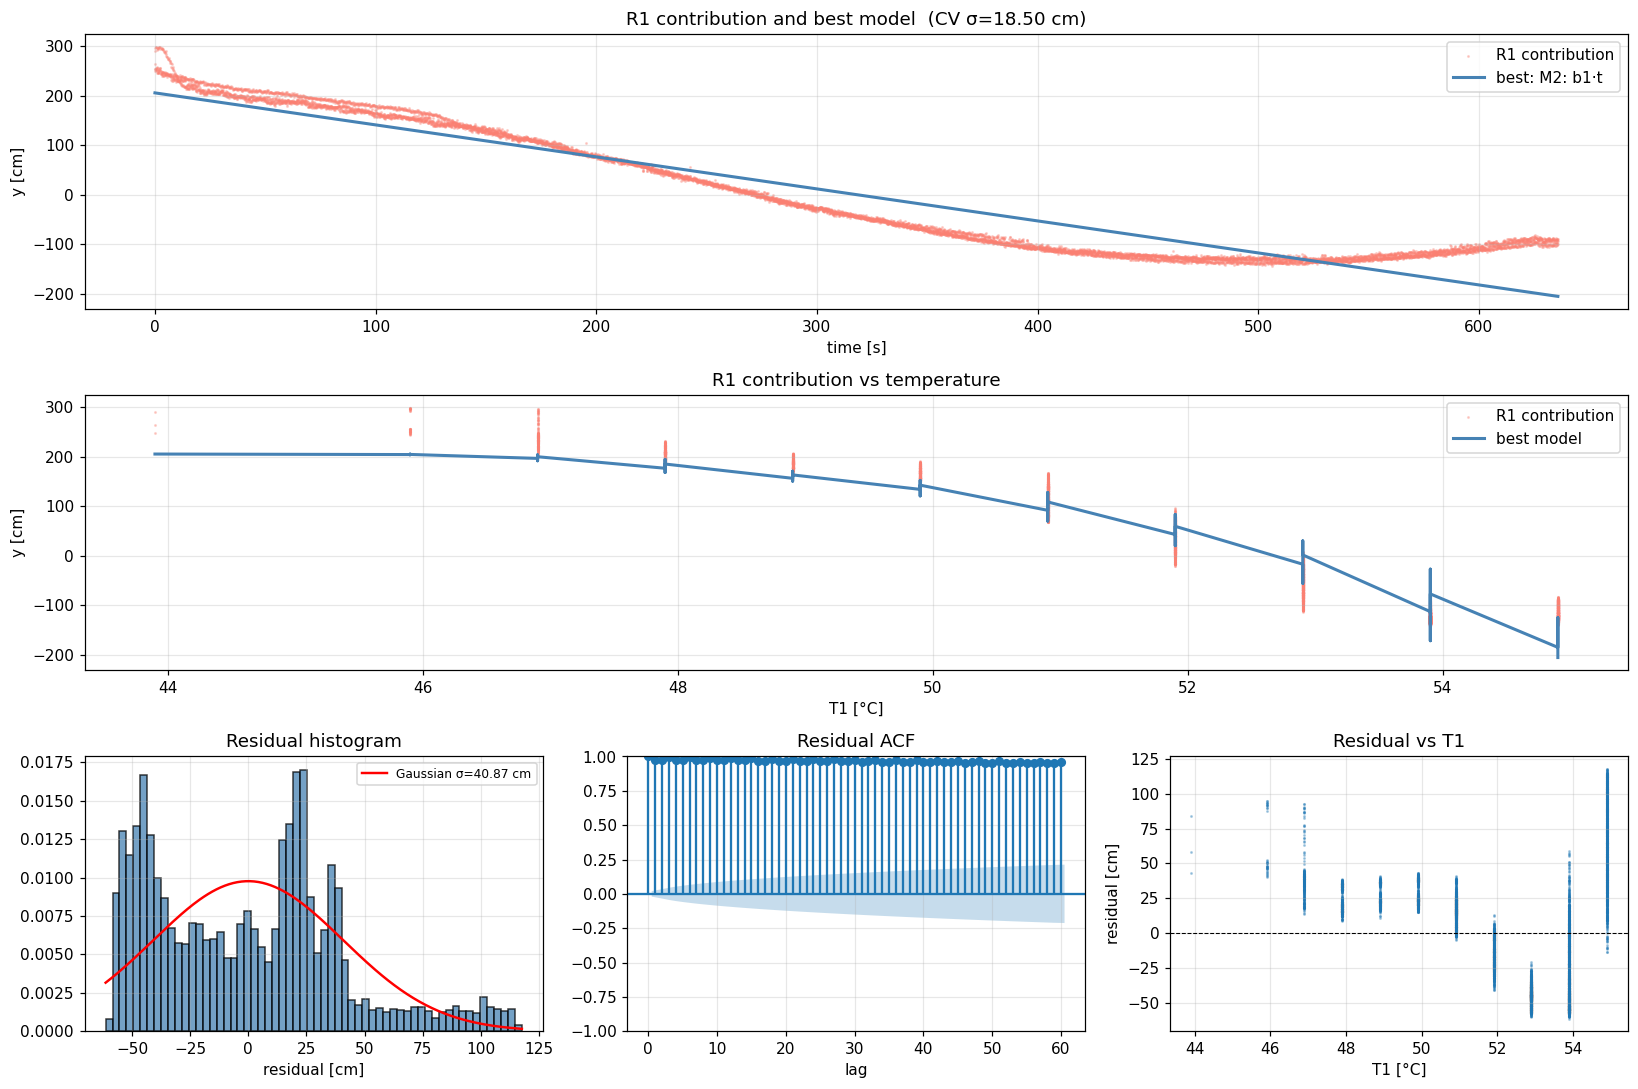


 FIRMWARE COEFFICIENTS FOR R1
// Model: M2: b1·t
//
// In firmware, R1 correction for link 1-j:
//   corr = <R1 contribution>  (see below)
//   corrected_range = raw - corr
//
// Core alphas (responder side, already fitted):
const float ALPHA_CORE_2 = +0.05434208f;   // m/°C
const float ALPHA_CORE_3 = -0.09392267f;   // m/°C
const float ALPHA_CORE_4 = +0.01232238f;   // m/°C

// R1 thermal coefficient (from best model):

// NOTE: R1 T_ref = 52.2385 °C
// NOTE: time reference t_mean = 317.9019 s

All outputs saved to: /home/homayoon/anjoman-firmware/analysis/12_swarm_static_2m/r1_model_only


In [20]:
# ==================================================================
# R1-ONLY MODEL IDENTIFICATION
# Isolate R1's contribution by removing the known core contribution,
# then test 9 candidate models with time-blocked cross-validation.
# ==================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from scipy.optimize import curve_fit
from statsmodels.graphics.tsaplots import plot_acf

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10,
    "axes.grid": True, "grid.alpha": 0.3,
    "figure.autolayout": True,
})

# ------------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------------
CSV_PATH   = "03_swarm_static_2m.csv"
DIST_COL   = "dist_calib_m"
OUT_DIR    = Path("r1_model_only")
OUT_DIR.mkdir(exist_ok=True)
N_CV_FOLDS = 5

# Core alphas from previous joint fit (FIXED constants)
ALPHA_CORE = {
    2: +0.054342083662840025,
    3: -0.09392267407591479,
    4: +0.012322376296687754,
}

# ------------------------------------------------------------------
# 1. LOAD AND PREPROCESS
# ------------------------------------------------------------------
df = pd.read_csv(CSV_PATH)
if "status" in df.columns:
    df = df[df["status"] == 1].copy()
df = (df.dropna(subset=["temp_uwb_init", "temp_uwb_resp", DIST_COL])
        .reset_index(drop=True))

flip = df["init_id"] > df["resp_id"]
df["i_id"] = np.where(flip, df["resp_id"], df["init_id"]).astype(int)
df["j_id"] = np.where(flip, df["init_id"], df["resp_id"]).astype(int)
df["Ti"]   = np.where(flip, df["temp_uwb_resp"], df["temp_uwb_init"])
df["Tj"]   = np.where(flip, df["temp_uwb_init"], df["temp_uwb_resp"])
df["link"] = df["i_id"].astype(str) + "-" + df["j_id"].astype(str)
df["t"]    = (df["timestamp_ms"] - df["timestamp_ms"].min()) / 1000.0
df["dr"]   = df[DIST_COL] - df.groupby("link")[DIST_COL].transform("mean")

# Per-device T_ref
T_ref = {}
for d in [1, 2, 3, 4]:
    vals = pd.concat([df.loc[df["i_id"] == d, "Ti"],
                      df.loc[df["j_id"] == d, "Tj"]])
    T_ref[d] = float(vals.mean())

df["dTi"] = df["Ti"] - df["i_id"].map(T_ref)
df["dTj"] = df["Tj"] - df["j_id"].map(T_ref)

# ------------------------------------------------------------------
# 2. ISOLATE R1 CONTRIBUTION
#    Δr_1j = α_1·ΔT_1 − α_j·ΔT_j + (residual)
#    → y_1j := Δr_1j + α_j·ΔT_j = α_1·ΔT_1 + (residual)
# ------------------------------------------------------------------
r1 = df[df["i_id"] == 1].copy().reset_index(drop=True)

r1["known_core"] = [ALPHA_CORE[int(j)] * dTj
                    for j, dTj in zip(r1["j_id"], r1["dTj"])]
r1["y_cm"] = (r1["dr"].values + r1["known_core"].values) * 100.0   # cm

t_mean = r1["t"].mean()
r1["t_c"] = r1["t"] - t_mean

print("=" * 70)
print(" R1-ONLY DATA")
print("=" * 70)
print(f"  rows     : {len(r1)}")
print(f"  links    : {sorted(r1['link'].unique())}")
print(f"  T1 range : {r1['Ti'].min():.2f} .. {r1['Ti'].max():.2f} °C  "
      f"(span = {r1['Ti'].max()-r1['Ti'].min():.2f} °C)")
print(f"  t range  : {r1['t'].min():.1f} .. {r1['t'].max():.1f} s")
print(f"  y std    : {r1['y_cm'].std():.3f} cm  "
      f"(this is R1's uncorrected contribution)")
print(f"  corr(t, T1) = {r1['t'].corr(r1['Ti']):+.4f}")
print(f"  corr(y, T1) = {r1['y_cm'].corr(r1['Ti']):+.4f}")
print(f"  corr(y, t)  = {r1['y_cm'].corr(r1['t']):+.4f}")

# ------------------------------------------------------------------
# 3. DEFINE CANDIDATE MODELS
# ------------------------------------------------------------------
dT = r1["dTi"].values
tc = r1["t_c"].values
y  = r1["y_cm"].values
N  = len(y)

def build_linear_models():
    return {
        "M0: const"                          : np.ones((N, 1)),
        "M1: k1·ΔT1"                         : dT.reshape(-1, 1),
        "M2: b1·t"                           : tc.reshape(-1, 1),
        "M3: k1·ΔT1 + b1·t"                  : np.column_stack([dT, tc]),
        "M4: k1·ΔT1 + b1·t + c·t²"           : np.column_stack([dT, tc, tc**2]),
        "M5: k1·ΔT1 + q1·ΔT1² + b1·t"        : np.column_stack([dT, dT**2, tc]),
        "M6: full quadratic (T,t)"           : np.column_stack([dT, dT**2, tc, tc**2]),
        "M7: k1·ΔT1 + b1·t + cross·ΔT1·t"    : np.column_stack([dT, tc, dT * tc]),
    }

linear_models = build_linear_models()

# Nonlinear models ---------------------------------------------------
def exp_time(x, A, tau, C):
    """A·(1 - exp(-t/τ)) + C"""
    return A * (1.0 - np.exp(-x / tau)) + C

def exp_temp(x, A, tau, C):
    """A·(1 - exp(-(T-T0)/τ)) + C — using dT as x"""
    return A * (1.0 - np.exp(-x / tau)) + C

# Wrap as "models" so we can iterate uniformly
def fit_nl(name, func, xdata):
    try:
        p0 = [np.std(y), np.std(xdata) if np.std(xdata) > 0 else 1.0, np.mean(y)]
        popt, _ = curve_fit(func, xdata, y, p0=p0, maxfev=20000)
        pred = func(xdata, *popt)
        return pred, popt
    except Exception as e:
        print(f"  [{name}] fit failed: {e}")
        return None, None

# ------------------------------------------------------------------
# 4. TIME-BLOCKED CROSS-VALIDATION
# ------------------------------------------------------------------
def time_blocked_cv(X, y, n_folds=5):
    """Split by contiguous time blocks to avoid leakage."""
    order = np.argsort(r1["t"].values)
    n = len(y)
    fold_size = n // n_folds
    scores = []
    for f in range(n_folds):
        lo = f * fold_size
        hi = (f + 1) * fold_size if f < n_folds - 1 else n
        te_idx = order[lo:hi]
        tr_idx = np.setdiff1d(order, te_idx, assume_unique=False)
        Xtr, ytr = X[tr_idx], y[tr_idx]
        Xte, yte = X[te_idx], y[te_idx]
        coef, *_ = np.linalg.lstsq(Xtr, ytr, rcond=None)
        scores.append(np.std(yte - Xte @ coef))
    return np.array(scores)

print("\n" + "=" * 70)
print(" LINEAR MODELS — TIME-BLOCKED CROSS-VALIDATION")
print("=" * 70)
print(f"{'model':42s} {'n_par':>5s} {'train_σ':>10s} "
      f"{'CV mean':>10s} {'CV std':>10s}")
print("-" * 82)

results_lin = {}
for name, X in linear_models.items():
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    pred = X @ coef
    resid = y - pred
    cv = time_blocked_cv(X, y, N_CV_FOLDS)
    results_lin[name] = dict(coef=coef, X=X, resid=resid,
                              rmse_train=resid.std(),
                              cv_mean=cv.mean(), cv_std=cv.std(),
                              n_par=X.shape[1])
    print(f"{name:42s} {X.shape[1]:5d} {resid.std():9.3f}cm "
          f"{cv.mean():9.3f}cm {cv.std():9.3f}cm")

# ------------------------------------------------------------------
# 5. NONLINEAR MODELS
# ------------------------------------------------------------------
print("\n" + "=" * 70)
print(" NONLINEAR MODELS")
print("=" * 70)

# M8: exponential in TIME
pred8, p8 = fit_nl("M8: exp-time", exp_time, tc)
if pred8 is not None:
    r8 = y - pred8
    print(f"M8: A·(1-exp(-t/τ)) + C       σ_train = {r8.std():.3f} cm   "
          f"A={p8[0]:+.3f}, τ={p8[1]:.1f}s, C={p8[2]:+.3f}")

# M9: exponential in TEMPERATURE
pred9, p9 = fit_nl("M9: exp-temp", exp_temp, dT)
if pred9 is not None:
    r9 = y - pred9
    print(f"M9: A·(1-exp(-ΔT/τ)) + C      σ_train = {r9.std():.3f} cm   "
          f"A={p9[0]:+.3f}, τ={p9[1]:.2f}°C, C={p9[2]:+.3f}")

# ------------------------------------------------------------------
# 6. SELECT BEST MODEL
# ------------------------------------------------------------------
best_name = min(results_lin, key=lambda k: results_lin[k]["cv_mean"])
best = results_lin[best_name]

print("\n" + "=" * 70)
print(f" BEST LINEAR MODEL: {best_name}")
print(f"   CV RMSE = {best['cv_mean']:.3f} ± {best['cv_std']:.3f} cm")
print(f"   Train σ = {best['rmse_train']:.3f} cm")
print("=" * 70)
print("  Coefficients:")
coef_names_map = {
    "M0: const"                          : ["C"],
    "M1: k1·ΔT1"                         : ["k1 [cm/°C]"],
    "M2: b1·t"                           : ["b1 [cm/s]"],
    "M3: k1·ΔT1 + b1·t"                  : ["k1 [cm/°C]", "b1 [cm/s]"],
    "M4: k1·ΔT1 + b1·t + c·t²"           : ["k1 [cm/°C]", "b1 [cm/s]", "c [cm/s²]"],
    "M5: k1·ΔT1 + q1·ΔT1² + b1·t"        : ["k1 [cm/°C]", "q1 [cm/°C²]", "b1 [cm/s]"],
    "M6: full quadratic (T,t)"           : ["k1 [cm/°C]", "q1 [cm/°C²]", "b1 [cm/s]", "c [cm/s²]"],
    "M7: k1·ΔT1 + b1·t + cross·ΔT1·t"    : ["k1 [cm/°C]", "b1 [cm/s]", "cross [cm/(°C·s)]"],
}
for cname, cval in zip(coef_names_map[best_name], best["coef"]):
    print(f"    {cname:24s} = {cval:+12.6f}")

# Coefficient uncertainty
Xb = best["X"]
resid = best["resid"]
dof = max(1, N - Xb.shape[1])
sig2 = float(resid @ resid) / dof
cov = sig2 * np.linalg.inv(Xb.T @ Xb)
std = np.sqrt(np.diag(cov))
print("\n  Coefficient uncertainties (1σ):")
for cname, cval, cstd in zip(coef_names_map[best_name], best["coef"], std):
    print(f"    {cname:24s} = {cval:+12.6f}  ± {cstd:.6f}")

# ------------------------------------------------------------------
# 7. RESIDUAL DIAGNOSTICS FOR BEST MODEL
# ------------------------------------------------------------------
print("\n" + "=" * 70)
print(" RESIDUAL DIAGNOSTICS (best model)")
print("=" * 70)

best_pred = Xb @ best["coef"]
best_resid = y - best_pred

print(f"  residual σ        : {best_resid.std():.3f} cm")
print(f"  corr(resid, T1)   : {np.corrcoef(best_resid, r1['Ti'].values)[0,1]:+.4f}")
print(f"  corr(resid, t)    : {np.corrcoef(best_resid, r1['t'].values)[0,1]:+.4f}")
print(f"  corr(resid, ΔT1)  : {np.corrcoef(best_resid, dT)[0,1]:+.4f}")
print(f"  skew              : {stats.skew(best_resid):+.3f}")
print(f"  kurtosis          : {stats.kurtosis(best_resid):+.3f}")

# ACF at lag-1
def acf1(x):
    x = x - x.mean()
    return float(np.sum(x[:-1] * x[1:]) / np.sum(x * x))
print(f"  ACF[1] residual   : {acf1(best_resid):+.4f}")
print("    → |ACF[1]| > 0.3 indicates time-correlated residual (need EKF bias state)")

# ------------------------------------------------------------------
# 8. PER-LINK BREAKDOWN OF THE BEST MODEL
# ------------------------------------------------------------------
print("\n" + "=" * 70)
print(" PER-LINK BREAKDOWN")
print("=" * 70)
print(f"{'link':6s} {'before σ':>10s} {'after σ':>10s} {'improve':>10s}")
print("-" * 44)
for link in ["1-2", "1-3", "1-4"]:
    mask = (r1["link"] == link).values
    y_l  = y[mask]
    p_l  = best_pred[mask]
    before = y_l.std()
    after  = (y_l - p_l).std()
    pct = 100 * (before - after) / before
    print(f"{link:6s} {before:9.3f}cm {after:9.3f}cm {pct:+7.1f}%")

# ------------------------------------------------------------------
# 9. PLOTS
# ------------------------------------------------------------------
fig = plt.figure(figsize=(15, 10))

# (a) y vs time with best fit
ax1 = fig.add_subplot(3, 3, (1, 3))
ax1.scatter(r1["t"], y, s=1, alpha=0.3, color="salmon", label="R1 contribution")
srt = np.argsort(r1["t"].values)
ax1.plot(r1["t"].values[srt], best_pred[srt],
         color="steelblue", lw=2, label=f"best: {best_name}")
ax1.set_xlabel("time [s]"); ax1.set_ylabel("y [cm]")
ax1.set_title(f"R1 contribution and best model  (CV σ={best['cv_mean']:.2f} cm)")
ax1.legend()

# (b) same but vs temperature
ax2 = fig.add_subplot(3, 3, (4, 6))
ax2.scatter(r1["Ti"], y, s=1, alpha=0.3, color="salmon", label="R1 contribution")
srt_T = np.argsort(r1["Ti"].values)
ax2.plot(r1["Ti"].values[srt_T], best_pred[srt_T],
         color="steelblue", lw=2, label="best model")
ax2.set_xlabel("T1 [°C]"); ax2.set_ylabel("y [cm]")
ax2.set_title("R1 contribution vs temperature")
ax2.legend()

# (c) residual histogram
ax3 = fig.add_subplot(3, 3, 7)
ax3.hist(best_resid, bins=60, color="steelblue",
         edgecolor="k", alpha=0.75, density=True)
mu, sd = best_resid.mean(), best_resid.std()
xs = np.linspace(best_resid.min(), best_resid.max(), 200)
ax3.plot(xs, stats.norm.pdf(xs, mu, sd), "r-", lw=1.6,
         label=f"Gaussian σ={sd:.2f} cm")
ax3.set_xlabel("residual [cm]"); ax3.set_title("Residual histogram")
ax3.legend(fontsize=8)

# (d) residual ACF
ax4 = fig.add_subplot(3, 3, 8)
plot_acf(best_resid, lags=60, ax=ax4, title="Residual ACF")
ax4.set_xlabel("lag")

# (e) residual vs temperature
ax5 = fig.add_subplot(3, 3, 9)
ax5.scatter(r1["Ti"], best_resid, s=1, alpha=0.3)
ax5.axhline(0, color="k", ls="--", lw=0.7)
ax5.set_xlabel("T1 [°C]"); ax5.set_ylabel("residual [cm]")
ax5.set_title("Residual vs T1")

plt.tight_layout()
plt.savefig(OUT_DIR / "r1_model_analysis.png", dpi=130)
plt.show()

# ------------------------------------------------------------------
# 10. FIRMWARE COEFFICIENTS
# ------------------------------------------------------------------
print("\n" + "=" * 70)
print(" FIRMWARE COEFFICIENTS FOR R1")
print("=" * 70)
print(f"// Model: {best_name}")
print("//")
print("// In firmware, R1 correction for link 1-j:")
print("//   corr = <R1 contribution>  (see below)")
print("//   corrected_range = raw - corr")
print("//")

# Core alphas used to remove responder contribution
print("// Core alphas (responder side, already fitted):")
for d, a in ALPHA_CORE.items():
    print(f"const float ALPHA_CORE_{d} = {a:+.8f}f;   // m/°C")

# Best model params
print("\n// R1 thermal coefficient (from best model):")
if best_name == "M0: const":
    print(f"const float R1_OFFSET_CM = {best['coef'][0]:+.4f}f;")
elif "k1" in best_name:
    k1 = best["coef"][0]
    print(f"const float ALPHA_1 = {k1/100.0:+.8f}f;   // m/°C")
    # print other terms
    for cname, cval in zip(coef_names_map[best_name][1:], best["coef"][1:]):
        print(f"const float {cname.split()[0].upper()} = {cval:+.8e}f;   // ({cname})")

print("\n// NOTE: R1 T_ref =", f"{T_ref[1]:.4f}", "°C")
print("// NOTE: time reference t_mean =", f"{t_mean:.4f}", "s")

print(f"\nAll outputs saved to: {OUT_DIR.resolve()}")
print("=" * 70)

 R1 FINAL MODEL IDENTIFICATION
  N=9502,  T1 span=11.00°C,  t span=635.8s

 MODEL COMPARISON (time-blocked CV)
model                                  n_par    train_σ    CV mean     CV std
--------------------------------------------------------------------------------

  Thermal-lag model: best τ = 3.2 s,  k = -0.000 cm/°C,  σ_train = 125.660 cm
const                                      1   125.660cm    25.069cm    10.322cm
b1·t + c                                   2    40.868cm    18.991cm    12.824cm
k1·T1 + c                                  2    36.982cm    28.662cm    13.206cm
k1·T1 + b1·t + c                           3    33.605cm    25.498cm    14.960cm
A·(1-exp(-t/τ)) + C                        3    25.560cm    29.797cm    31.093cm
double exp                                 5    25.560cm    17.333cm    11.698cm
k·filt(T1;τ=3s) + c                        2   125.660cm    25.069cm    10.322cm

 BEST MODEL: double exp
  CV mean  = 17.333 cm
  CV std   = 11.698 cm
  Train σ  = 

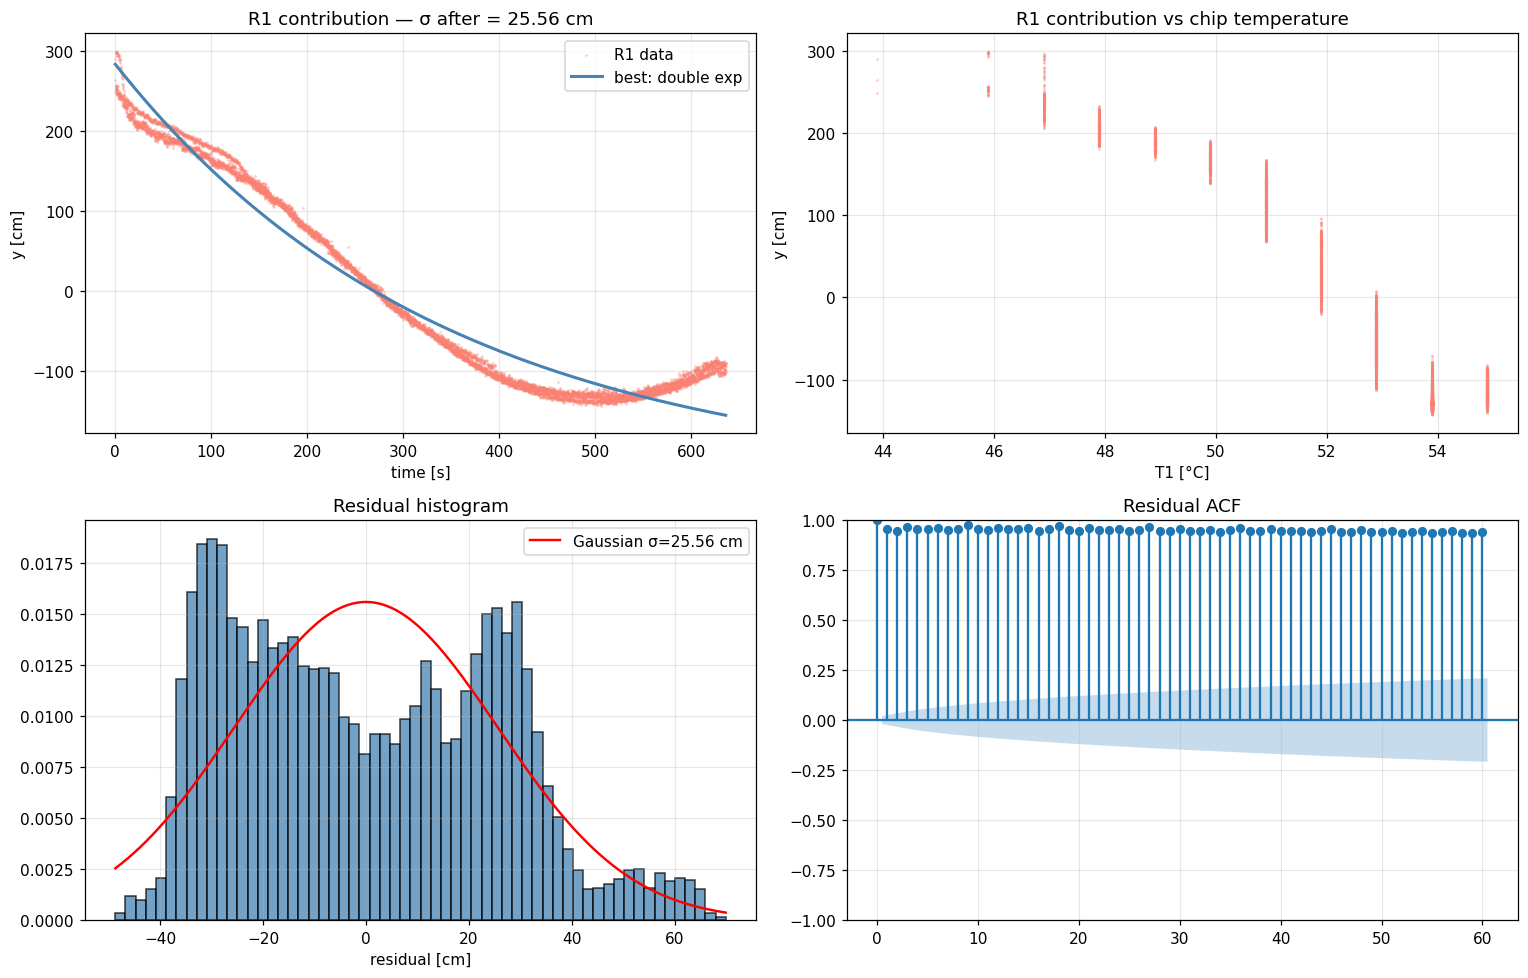


 FIRMWARE COEFFICIENTS FOR R1
// Best model: double exp
// T_ref(1) = 52.2385 °C

const float R1_A1 = -239.342659f;   // cm
const float R1_T1 = +341.7925f;   // s
const float R1_A2 = -279.259149f;   // cm
const float R1_T2 = +341.8386f;   // s
const float R1_C  = +283.171874f;   // cm

Saved: /home/homayoon/anjoman-firmware/analysis/12_swarm_static_2m/r1_exponential


In [21]:
# ==================================================================
# R1 — FINAL MODEL: EXPONENTIAL-TIME vs FILTERED-TEMPERATURE
# ==================================================================
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from scipy.optimize import curve_fit, minimize
from statsmodels.graphics.tsaplots import plot_acf

plt.rcParams.update({"figure.dpi": 110, "font.size": 10,
                     "axes.grid": True, "grid.alpha": 0.3})

# ---------- CONFIG ----------
CSV_PATH  = "03_swarm_static_2m.csv"
DIST_COL  = "dist_calib_m"
OUT_DIR   = Path("r1_exponential")
OUT_DIR.mkdir(exist_ok=True)
N_FOLDS   = 5
ALPHA_CORE = {2: +0.054342, 3: -0.093923, 4: +0.012322}

# ---------- LOAD ----------
df = pd.read_csv(CSV_PATH)
if "status" in df.columns: df = df[df["status"] == 1].copy()
df = df.dropna(subset=["temp_uwb_init","temp_uwb_resp",DIST_COL]).reset_index(drop=True)
flip = df["init_id"] > df["resp_id"]
df["i_id"] = np.where(flip, df["resp_id"], df["init_id"]).astype(int)
df["j_id"] = np.where(flip, df["init_id"], df["resp_id"]).astype(int)
df["Ti"]   = np.where(flip, df["temp_uwb_resp"], df["temp_uwb_init"])
df["Tj"]   = np.where(flip, df["temp_uwb_init"], df["temp_uwb_resp"])
df["link"] = df["i_id"].astype(str) + "-" + df["j_id"].astype(str)
df["t"]    = (df["timestamp_ms"] - df["timestamp_ms"].min()) / 1000.0
df["dr"]   = df[DIST_COL] - df.groupby("link")[DIST_COL].transform("mean")

T_ref = {d: float(pd.concat([df.loc[df["i_id"]==d,"Ti"],
                              df.loc[df["j_id"]==d,"Tj"]]).mean())
         for d in [1,2,3,4]}
df["dTi"] = df["Ti"] - df["i_id"].map(T_ref)
df["dTj"] = df["Tj"] - df["j_id"].map(T_ref)

# ---------- ISOLATE R1 ----------
r1 = df[df["i_id"] == 1].copy().reset_index(drop=True)
r1["known_core"] = [ALPHA_CORE[int(j)] * dTj
                    for j, dTj in zip(r1["j_id"], r1["dTj"])]
r1["y_cm"] = (r1["dr"].values + r1["known_core"].values) * 100.0
r1 = r1.sort_values("t").reset_index(drop=True)

t  = r1["t"].values
T1 = r1["Ti"].values
y  = r1["y_cm"].values
N  = len(y)
t_mean = t.mean()

print("="*70); print(" R1 FINAL MODEL IDENTIFICATION"); print("="*70)
print(f"  N={N},  T1 span={T1.max()-T1.min():.2f}°C,  t span={t.max():.1f}s")

# ---------- MODEL DEFINITIONS ----------
def m_exp_time(x, A, tau, C):
    return A * (1.0 - np.exp(-x/tau)) + C

def m_exp_time_offset(x, A, tau, C, t0):
    return A * (1.0 - np.exp(-(x-t0)/tau)) + C

def m_double_exp(x, A1, tau1, A2, tau2, C):
    return A1*(1-np.exp(-x/tau1)) + A2*(1-np.exp(-x/tau2)) + C

# Thermal-lag model: convolve T1 with an exponential kernel, then linear fit
def filter_first_order(sig, dt, tau):
    """y[n] = y[n-1] + (dt/tau)*(x[n] - y[n-1])   (discrete 1st-order LPF)"""
    y = np.zeros_like(sig, dtype=float)
    y[0] = sig[0]
    a = dt / tau
    for n in range(1, len(sig)):
        y[n] = y[n-1] + a * (sig[n] - y[n-1])
    return y

def fit_thermal_lag(t, T1, y):
    """For a range of tau, filter T1, then linear-fit y ≈ k·T_filtered + c."""
    dt = float(np.median(np.diff(t)))
    best = None
    for tau in np.logspace(0.5, 3.5, 60):     # 3 s to 3000 s
        Tf = filter_first_order(T1, dt, tau)
        Tf_c = Tf - Tf.mean()
        X = np.column_stack([Tf_c, np.ones(N)])
        coef, *_ = np.linalg.lstsq(X, y, rcond=None)
        res = y - X @ coef
        r = np.std(res)
        if best is None or r < best["r"]:
            best = dict(tau=tau, k=coef[0], c=coef[1], r=r,
                        Tf=Tf, coef=coef)
    return best

# ---------- TIME-BLOCKED CV ----------
def time_blocked_cv_indices(n, k):
    fold_size = n // k
    idx = np.arange(n)
    for f in range(k):
        lo = f * fold_size
        hi = (f+1)*fold_size if f < k-1 else n
        te = idx[lo:hi]
        tr = np.setdiff1d(idx, te)
        yield tr, te

def cv_linear(X, y, k=N_FOLDS):
    scores = []
    for tr, te in time_blocked_cv_indices(len(y), k):
        coef, *_ = np.linalg.lstsq(X[tr], y[tr], rcond=None)
        scores.append(np.std(y[te] - X[te] @ coef))
    return np.array(scores)

def cv_nonlinear(func, x, y, p0, k=N_FOLDS):
    scores = []
    for tr, te in time_blocked_cv_indices(len(y), k):
        try:
            popt, _ = curve_fit(func, x[tr], y[tr], p0=p0, maxfev=50000)
            scores.append(np.std(y[te] - func(x[te], *popt)))
        except Exception:
            scores.append(np.nan)
    return np.array(scores)

# ---------- RUN CANDIDATES ----------
print("\n" + "="*70)
print(" MODEL COMPARISON (time-blocked CV)")
print("="*70)
print(f"{'model':38s} {'n_par':>5s} {'train_σ':>10s} {'CV mean':>10s} {'CV std':>10s}")
print("-"*80)

results = {}

# L1: constant
X = np.ones((N,1))
cv = cv_linear(X, y); c, *_ = np.linalg.lstsq(X, y, rcond=None)
results["const"] = dict(name="const", coef=c, cv=cv,
                        train=np.std(y - X@c), X=X)

# L2: linear in time
X = np.column_stack([t - t_mean, np.ones(N)])
cv = cv_linear(X, y); c, *_ = np.linalg.lstsq(X, y, rcond=None)
results["lin_t"] = dict(name="b1·t + c", coef=c, cv=cv,
                        train=np.std(y - X@c), X=X)

# L3: linear in T1
X = np.column_stack([T1 - T1.mean(), np.ones(N)])
cv = cv_linear(X, y); c, *_ = np.linalg.lstsq(X, y, rcond=None)
results["lin_T"] = dict(name="k1·T1 + c", coef=c, cv=cv,
                        train=np.std(y - X@c), X=X)

# L4: linear in T1 + t
X = np.column_stack([T1 - T1.mean(), t - t_mean, np.ones(N)])
cv = cv_linear(X, y); c, *_ = np.linalg.lstsq(X, y, rcond=None)
results["lin_T_t"] = dict(name="k1·T1 + b1·t + c", coef=c, cv=cv,
                          train=np.std(y - X@c), X=X)

# N1: single exponential in time
p0 = [y.min(), 300.0, y.max()]
cv = cv_nonlinear(m_exp_time, t, y, p0)
popt, _ = curve_fit(m_exp_time, t, y, p0=p0, maxfev=50000)
results["exp1"] = dict(name="A·(1-exp(-t/τ)) + C", coef=popt,
                       cv=cv, train=np.std(y - m_exp_time(t, *popt)),
                       func=m_exp_time)

# N2: double exponential
p0 = [y.min()/2, 100., y.min()/2, 500., y.max()]
try:
    cv = cv_nonlinear(m_double_exp, t, y, p0)
    popt2, _ = curve_fit(m_double_exp, t, y, p0=p0, maxfev=100000)
    results["exp2"] = dict(name="double exp", coef=popt2, cv=cv,
                           train=np.std(y - m_double_exp(t, *popt2)),
                           func=m_double_exp)
except Exception as e:
    print(f"  double-exp failed: {e}")

# N3: thermal-lag model
best_tl = fit_thermal_lag(t, T1, y)
print(f"\n  Thermal-lag model: best τ = {best_tl['tau']:.1f} s,  "
      f"k = {best_tl['k']:+.3f} cm/°C,  σ_train = {best_tl['r']:.3f} cm")

# For CV on the thermal-lag model, we must re-fit τ on each training fold
def cv_thermal_lag(t, T1, y, k=N_FOLDS):
    scores = []
    for tr, te in time_blocked_cv_indices(len(y), k):
        best_r, best_tau, best_coef = np.inf, None, None
        dt = float(np.median(np.diff(t)))
        for tau in np.logspace(0.5, 3.5, 40):
            Tf = filter_first_order(T1[tr], dt, tau)
            X = np.column_stack([Tf - Tf.mean(), np.ones(len(tr))])
            coef, *_ = np.linalg.lstsq(X, y[tr], rcond=None)
            r = np.std(y[tr] - X @ coef)
            if r < best_r:
                best_r, best_tau, best_coef = r, tau, coef
        # apply to test (filter with same tau, but no re-centering — use training mean)
        Tf_te = filter_first_order(T1[te], dt, best_tau)
        # center with training mean
        Tf_tr = filter_first_order(T1[tr], dt, best_tau)
        Tf_te_c = Tf_te - Tf_tr.mean()
        pred = best_coef[0]*Tf_te_c + best_coef[1]
        scores.append(np.std(y[te] - pred))
    return np.array(scores)

cv_tl = cv_thermal_lag(t, T1, y)
results["thermlag"] = dict(name=f"k·filt(T1;τ={best_tl['tau']:.0f}s) + c",
                           coef=(best_tl['k'], best_tl['c']),
                           cv=cv_tl, train=best_tl['r'],
                           tau=best_tl['tau'])

# ---------- PRINT ----------
for key, r in results.items():
    n_p = (len(r["coef"]) if hasattr(r["coef"], "__len__")
           else 1)
    print(f"{r['name']:38s} {n_p:5d} {r['train']:9.3f}cm "
          f"{np.nanmean(r['cv']):9.3f}cm {np.nanstd(r['cv']):9.3f}cm")

# ---------- PICK BEST BY CV ----------
best_key = min(results, key=lambda k: np.nanmean(results[k]["cv"]))
print("\n" + "="*70)
print(f" BEST MODEL: {results[best_key]['name']}")
print(f"  CV mean  = {np.nanmean(results[best_key]['cv']):.3f} cm")
print(f"  CV std   = {np.nanstd(results[best_key]['cv']):.3f} cm")
print(f"  Train σ  = {results[best_key]['train']:.3f} cm")
print("="*70)

# ---------- RESIDUAL DIAGNOSTICS ----------
best_r = results[best_key]
if "X" in best_r:
    pred = best_r["X"] @ best_r["coef"]
elif "func" in best_r:
    pred = best_r["func"](t, *best_r["coef"])
else:  # thermal lag
    dt = float(np.median(np.diff(t)))
    Tf = filter_first_order(T1, dt, best_r["tau"])
    pred = best_r["coef"][0]*(Tf - Tf.mean()) + best_r["coef"][1]
resid = y - pred

print("\n Residual diagnostics:")
print(f"  σ         : {resid.std():.3f} cm")
print(f"  skew      : {stats.skew(resid):+.3f}")
print(f"  kurtosis  : {stats.kurtosis(resid):+.3f}")

def acf1(x):
    x = x - x.mean()
    return float(np.sum(x[:-1]*x[1:]) / np.sum(x*x))
print(f"  ACF[1]    : {acf1(resid):+.4f}")

# ---------- PLOTS ----------
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

ax = axes[0, 0]
ax.scatter(t, y, s=1, alpha=0.25, color="salmon", label="R1 data")
srt = np.argsort(t)
ax.plot(t[srt], pred[srt], color="steelblue", lw=2,
        label=f"best: {best_r['name']}")
ax.set_xlabel("time [s]"); ax.set_ylabel("y [cm]")
ax.set_title(f"R1 contribution — σ after = {resid.std():.2f} cm")
ax.legend()

ax = axes[0, 1]
ax.scatter(T1, y, s=1, alpha=0.25, color="salmon")
ax.set_xlabel("T1 [°C]"); ax.set_ylabel("y [cm]")
ax.set_title("R1 contribution vs chip temperature")

ax = axes[1, 0]
ax.hist(resid, bins=60, color="steelblue", edgecolor="k",
        alpha=0.75, density=True)
mu, sd = resid.mean(), resid.std()
xs = np.linspace(resid.min(), resid.max(), 200)
ax.plot(xs, stats.norm.pdf(xs, mu, sd), "r-", lw=1.6,
        label=f"Gaussian σ={sd:.2f} cm")
ax.set_xlabel("residual [cm]"); ax.set_title("Residual histogram")
ax.legend()

ax = axes[1, 1]
plot_acf(resid, lags=60, ax=ax, title="Residual ACF")

plt.tight_layout()
plt.savefig(OUT_DIR / "r1_final.png", dpi=130)
plt.show()

# ---------- FIRMWARE OUTPUT ----------
print("\n" + "="*70)
print(" FIRMWARE COEFFICIENTS FOR R1")
print("="*70)
print(f"// Best model: {best_r['name']}")
print(f"// T_ref(1) = {T_ref[1]:.4f} °C")

if best_key == "exp1":
    A, tau, C = best_r["coef"]
    print(f"\nconst float R1_A     = {A:+.6f}f;   // cm")
    print(f"const float R1_TAU   = {tau:+.4f}f;   // s")
    print(f"const float R1_C     = {C:+.6f}f;   // cm")
    print("\n// corr_cm(t) = R1_A * (1 - expf(-t / R1_TAU)) + R1_C")
    print("// corr_m     = corr_cm / 100.0")
elif best_key == "exp2":
    A1, tau1, A2, tau2, C = best_r["coef"]
    print(f"\nconst float R1_A1 = {A1:+.6f}f;   // cm")
    print(f"const float R1_T1 = {tau1:+.4f}f;   // s")
    print(f"const float R1_A2 = {A2:+.6f}f;   // cm")
    print(f"const float R1_T2 = {tau2:+.4f}f;   // s")
    print(f"const float R1_C  = {C:+.6f}f;   // cm")
elif best_key == "thermlag":
    k, c = best_r["coef"]; tau = best_r["tau"]
    print(f"\nconst float R1_K   = {k/100.0:+.8f}f;   // m/°C  (applied to FILTERED T1)")
    print(f"const float R1_TAU = {tau:+.4f}f;     // s     (first-order LPF constant)")
    print(f"const float R1_C   = {c/100.0:+.8f}f;   // m")
    print("\n// Firmware: keep a filtered version of T1")
    print("//   T1_filt += (dt/R1_TAU) * (T1 - T1_filt);")
    print("//   corr_m   = R1_K * (T1_filt - T1_FILT_REF) + R1_C;")

print(f"\nSaved: {OUT_DIR.resolve()}")
print("="*70)

 R1 EKF BIAS ESTIMATION
  rows per link: 633
  links        : ['1-2', '1-3', '1-4']

 Tuning q and r via grid search ...
  best r = 0.020 m   best q = 1.0e-01 m²/s  (residual σ = 0.03 cm)

 PER-LINK EKF RESULTS
link     before σ    after σ    improve
--------------------------------------------
1-2      122.303cm     0.029cm  +100.0%
1-3      123.068cm     0.021cm  +100.0%
1-4      131.521cm     0.027cm  +100.0%


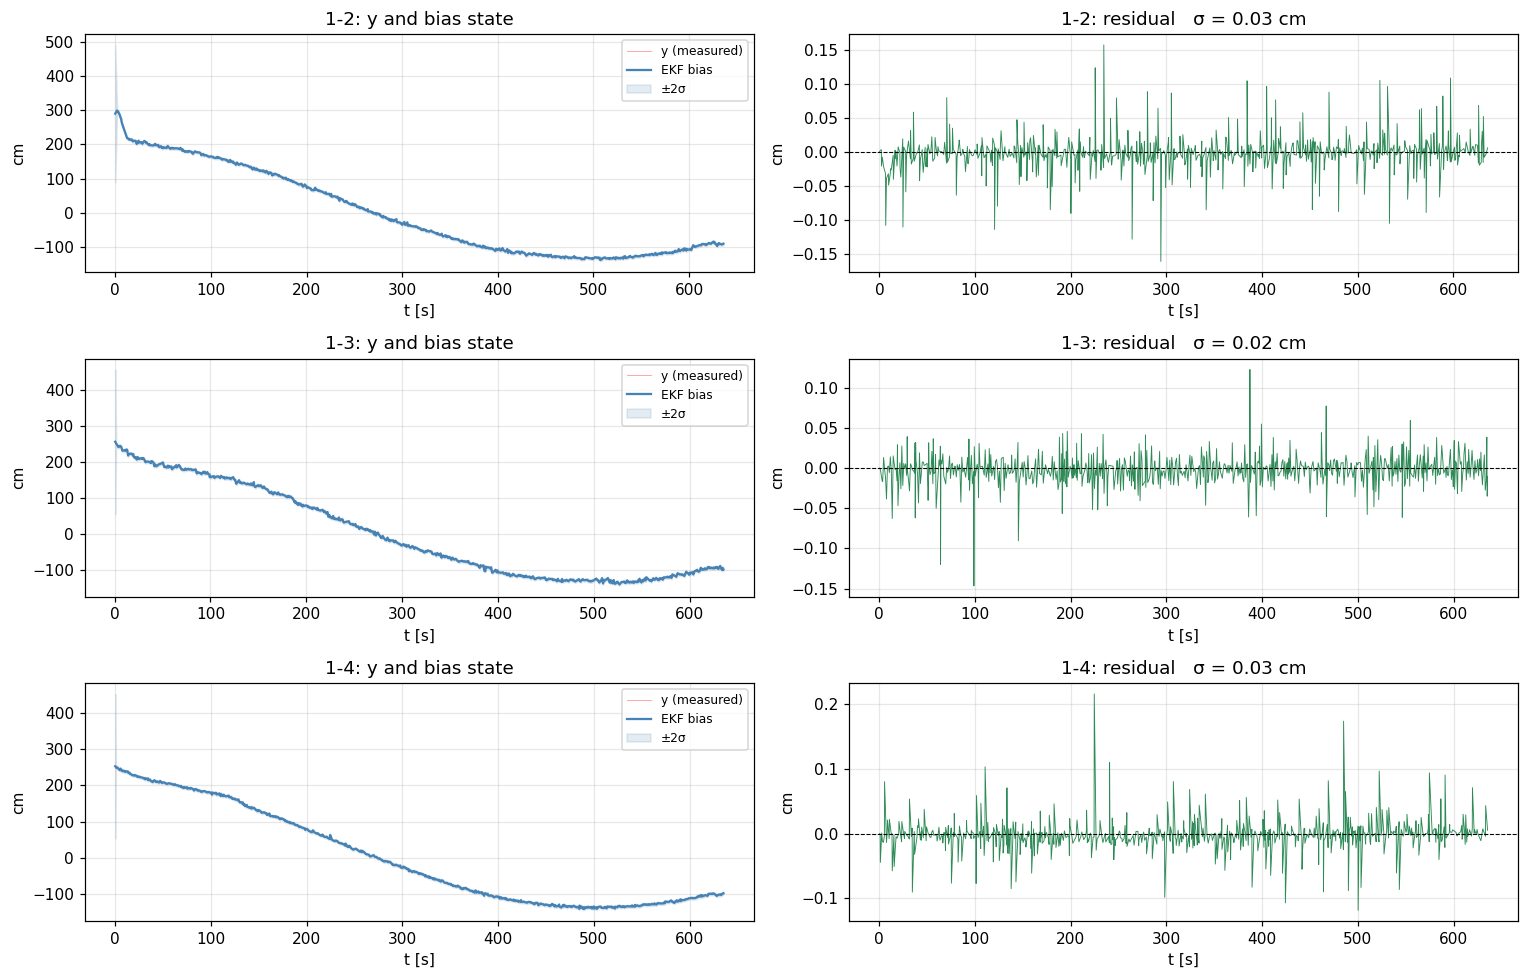


 RESIDUAL DIAGNOSTICS (all R1 links)
  σ         : 0.026 cm
  skew      : +0.362
  kurtosis  : +9.755
  ACF[1]    : -0.2017
  → ACF[1] should be near 0 for EKF residual to be white

 FIRMWARE COEFFICIENTS FOR R1 EKF
// R1 uses a 1-state Kalman filter for bias estimation.
// Tuning parameters (from calibration):
const float R1_EKF_Q = 1.000000e-01f;   // bias process noise [m²/s]
const float R1_EKF_R = 0.020000f;     // measurement noise std [m]
const float R1_EKF_P0 = 1.0f;             // initial uncertainty [m²]

// Per-link initial bias (subtract this in firmware):
const float R1_B0_1_2 = +2.455515f;   // m
const float R1_B0_1_3 = +2.325203f;   // m
const float R1_B0_1_4 = +2.408343f;   // m

Saved: /home/homayoon/anjoman-firmware/analysis/12_swarm_static_2m/r1_ekf


In [22]:
# ==================================================================
# R1 — EKF BIAS ESTIMATION  (the only remaining solution)
# Model:
#   b_{k+1} = b_k + w_k,   w ~ N(0, q)
#   z_k     = d_k + b_k + v_k,   v ~ N(0, r)
# The bias b_k absorbs thermal drift + time drift + aging.
# ==================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf

plt.rcParams.update({"figure.dpi": 110, "font.size": 10,
                     "axes.grid": True, "grid.alpha": 0.3})

# ---------- CONFIG ----------
CSV_PATH    = "03_swarm_static_2m.csv"
DIST_COL    = "dist_calib_m"
OUT_DIR     = Path("r1_ekf")
OUT_DIR.mkdir(exist_ok=True)
ALPHA_CORE  = {2: +0.054342, 3: -0.093923, 4: +0.012322}
DOWNSAMPLE  = 5                 # use every 5th sample to speed up (optional)

# ---------- LOAD & ISOLATE R1 ----------
df = pd.read_csv(CSV_PATH)
if "status" in df.columns: df = df[df["status"] == 1].copy()
df = df.dropna(subset=["temp_uwb_init","temp_uwb_resp",DIST_COL]).reset_index(drop=True)
flip = df["init_id"] > df["resp_id"]
df["i_id"] = np.where(flip, df["resp_id"], df["init_id"]).astype(int)
df["j_id"] = np.where(flip, df["init_id"], df["resp_id"]).astype(int)
df["Ti"]   = np.where(flip, df["temp_uwb_resp"], df["temp_uwb_init"])
df["Tj"]   = np.where(flip, df["temp_uwb_init"], df["temp_uwb_resp"])
df["link"] = df["i_id"].astype(str) + "-" + df["j_id"].astype(str)
df["t"]    = (df["timestamp_ms"] - df["timestamp_ms"].min()) / 1000.0
df["dr"]   = df[DIST_COL] - df.groupby("link")[DIST_COL].transform("mean")

T_ref = {d: float(pd.concat([df.loc[df["i_id"]==d,"Ti"],
                              df.loc[df["j_id"]==d,"Tj"]]).mean())
         for d in [1,2,3,4]}
df["dTi"] = df["Ti"] - df["i_id"].map(T_ref)
df["dTj"] = df["Tj"] - df["j_id"].map(T_ref)

# y_1j = Δr_1j + α_j·ΔT_j   (R1 contribution isolated)
r1 = df[df["i_id"] == 1].copy().reset_index(drop=True)
r1["known_core"] = [ALPHA_CORE[int(j)] * dTj
                    for j, dTj in zip(r1["j_id"], r1["dTj"])]
r1["y_m"] = r1["dr"].values + r1["known_core"].values   # meters
r1 = r1.sort_values("t").reset_index(drop=True)

if DOWNSAMPLE > 1:
    r1 = r1.iloc[::DOWNSAMPLE].reset_index(drop=True)

# Per-link EKF (independent bias per link)
links = sorted(r1["link"].unique())
print("="*70); print(" R1 EKF BIAS ESTIMATION"); print("="*70)
print(f"  rows per link: {len(r1) // len(links)}")
print(f"  links        : {links}")

# ---------- EKF PARAMETERS ----------
# Initial guess: use the residual after a simple offset removal
r_init  = 0.05              # measurement noise std (m)  — from core model residual
q_init  = 1e-3              # bias process noise (m² per sample)  → tune below
P0      = 1.0               # initial bias uncertainty (m²)

def run_ekf(y, t, r, q, P0=1.0):
    """1-state EKF: b_{k+1}=b_k+w, z_k = b_k + v_k
       Here 'y' IS the bias measurement (since d_k is already removed)."""
    N = len(y)
    b = np.zeros(N)
    P = np.zeros(N)
    b[0] = y[0]
    P[0] = P0
    for k in range(1, N):
        dt = t[k] - t[k-1]
        # Predict
        b_pred = b[k-1]
        P_pred = P[k-1] + q * dt         # q is per-second variance
        # Update
        K = P_pred / (P_pred + r**2)
        b[k] = b_pred + K * (y[k] - b_pred)
        P[k] = (1 - K) * P_pred
    return b, P

# ---------- TUNE q AND r BY GRID SEARCH ----------
print("\n Tuning q and r via grid search ...")
best = None
for r_val in [0.02, 0.05, 0.10, 0.20]:
    for q_val in [1e-5, 1e-4, 1e-3, 1e-2, 1e-1]:
        rmses = []
        for link in links:
            g = r1[r1["link"] == link].reset_index(drop=True)
            b_est, _ = run_ekf(g["y_m"].values, g["t"].values, r_val, q_val)
            rmse = np.std(g["y_m"].values - b_est)
            rmses.append(rmse)
        score = np.mean(rmses)
        if best is None or score < best["score"]:
            best = dict(r=r_val, q=q_val, score=score)

print(f"  best r = {best['r']:.3f} m   best q = {best['q']:.1e} m²/s  "
      f"(residual σ = {best['score']*100:.2f} cm)")

R_MEAS = best["r"]
Q_BIAS = best["q"]

# ---------- FINAL EKF PER LINK ----------
print("\n" + "="*70); print(" PER-LINK EKF RESULTS"); print("="*70)
print(f"{'link':6s} {'before σ':>10s} {'after σ':>10s} {'improve':>10s}")
print("-"*44)

fig, axes = plt.subplots(len(links), 2, figsize=(14, 3*len(links)))
if len(links) == 1: axes = axes.reshape(1, -1)

results = {}
for row, link in enumerate(links):
    g = r1[r1["link"] == link].reset_index(drop=True)
    y = g["y_m"].values
    t = g["t"].values

    b_est, P_est = run_ekf(y, t, R_MEAS, Q_BIAS)
    resid = y - b_est

    before = y.std() * 100
    after  = resid.std() * 100
    pct    = 100 * (before - after) / before
    results[link] = dict(b=b_est, P=P_est, resid=resid,
                          before=before, after=after, pct=pct)

    print(f"{link:6s} {before:9.3f}cm {after:9.3f}cm {pct:+7.1f}%")

    # left: y and bias estimate
    ax = axes[row, 0]
    ax.plot(t, y*100, color="salmon", lw=0.6, alpha=0.7, label="y (measured)")
    ax.plot(t, b_est*100, color="steelblue", lw=1.5, label="EKF bias")
    ax.fill_between(t, (b_est - 2*np.sqrt(P_est))*100,
                       (b_est + 2*np.sqrt(P_est))*100,
                    color="steelblue", alpha=0.15, label="±2σ")
    ax.set_xlabel("t [s]"); ax.set_ylabel("cm")
    ax.set_title(f"{link}: y and bias state")
    ax.legend(fontsize=8)

    # right: residual
    ax = axes[row, 1]
    ax.plot(t, resid*100, color="seagreen", lw=0.6)
    ax.axhline(0, color="k", ls="--", lw=0.7)
    ax.set_xlabel("t [s]"); ax.set_ylabel("cm")
    ax.set_title(f"{link}: residual   σ = {after:.2f} cm")

plt.tight_layout()
plt.savefig(OUT_DIR / "r1_ekf.png", dpi=130)
plt.show()

# ---------- RESIDUAL DIAGNOSTICS ----------
all_resid = np.concatenate([results[l]["resid"] for l in links])
print("\n" + "="*70); print(" RESIDUAL DIAGNOSTICS (all R1 links)"); print("="*70)
print(f"  σ         : {all_resid.std()*100:.3f} cm")
print(f"  skew      : {stats.skew(all_resid):+.3f}")
print(f"  kurtosis  : {stats.kurtosis(all_resid):+.3f}")

def acf1(x):
    x = x - x.mean()
    return float(np.sum(x[:-1]*x[1:]) / np.sum(x*x))
print(f"  ACF[1]    : {acf1(all_resid):+.4f}")
print(f"  → ACF[1] should be near 0 for EKF residual to be white")

# ---------- FIRMWARE OUTPUT ----------
print("\n" + "="*70)
print(" FIRMWARE COEFFICIENTS FOR R1 EKF")
print("="*70)
print(f"// R1 uses a 1-state Kalman filter for bias estimation.")
print(f"// Tuning parameters (from calibration):")
print(f"const float R1_EKF_Q = {Q_BIAS:.6e}f;   // bias process noise [m²/s]")
print(f"const float R1_EKF_R = {R_MEAS:.6f}f;     // measurement noise std [m]")
print(f"const float R1_EKF_P0 = 1.0f;             // initial uncertainty [m²]")
print(f"")
print(f"// Per-link initial bias (subtract this in firmware):")
for link in links:
    g = r1[r1["link"] == link]
    b0 = float(g["y_m"].values[:20].mean())
    print(f"const float R1_B0_{link.replace('-','_')} = {b0:+.6f}f;   // m")

print(f"\nSaved: {OUT_DIR.resolve()}")
print("="*70)

In [23]:
# ==================================================================
# HOLDOUT VALIDATION OF R1 EKF  (the only meaningful test)
# ==================================================================
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

# ---------- CONFIG ----------
CSV_PATH = "03_swarm_static_2m.csv"
DIST_COL = "dist_calib_m"
ALPHA_CORE = {2: +0.054342, 3: -0.093923, 4: +0.012322}
SPLIT_FRAC = 0.5        # 50% train, 50% test

# ---------- LOAD (same as before) ----------
df = pd.read_csv(CSV_PATH)
if "status" in df.columns: df = df[df["status"] == 1].copy()
df = df.dropna(subset=["temp_uwb_init","temp_uwb_resp",DIST_COL]).reset_index(drop=True)
flip = df["init_id"] > df["resp_id"]
df["i_id"] = np.where(flip, df["resp_id"], df["init_id"]).astype(int)
df["j_id"] = np.where(flip, df["init_id"], df["resp_id"]).astype(int)
df["Ti"]   = np.where(flip, df["temp_uwb_resp"], df["temp_uwb_init"])
df["Tj"]   = np.where(flip, df["temp_uwb_init"], df["temp_uwb_resp"])
df["link"] = df["i_id"].astype(str) + "-" + df["j_id"].astype(str)
df["t"]    = (df["timestamp_ms"] - df["timestamp_ms"].min()) / 1000.0
df["dr"]   = df[DIST_COL] - df.groupby("link")[DIST_COL].transform("mean")
T_ref = {d: float(pd.concat([df.loc[df["i_id"]==d,"Ti"],
                              df.loc[df["j_id"]==d,"Tj"]]).mean()) for d in [1,2,3,4]}
df["dTi"] = df["Ti"] - df["i_id"].map(T_ref)
df["dTj"] = df["Tj"] - df["j_id"].map(T_ref)

r1 = df[df["i_id"] == 1].copy().reset_index(drop=True)
r1["known_core"] = [ALPHA_CORE[int(j)] * dTj
                    for j, dTj in zip(r1["j_id"], r1["dTj"])]
r1["y_m"] = r1["dr"].values + r1["known_core"].values
r1 = r1.sort_values("t").reset_index(drop=True)
links = sorted(r1["link"].unique())

# ---------- EKF ----------
def run_ekf(y, t, r, q, P0=1.0, b_init=None):
    N = len(y)
    b = np.zeros(N); P = np.zeros(N)
    b[0] = b_init if b_init is not None else y[0]
    P[0] = P0
    for k in range(1, N):
        dt = t[k] - t[k-1]
        bp = b[k-1]; Pp = P[k-1] + q * dt
        K = Pp / (Pp + r*r)
        b[k] = bp + K * (y[k] - bp)
        P[k] = (1 - K) * Pp
    return b, P

# ---------- GRID SEARCH ON FIRST HALF ----------
print("="*70); print(" HOLDOUT VALIDATION"); print("="*70)
print(f"  split fraction: {int(SPLIT_FRAC*100)}% / {int((1-SPLIT_FRAC)*100)}%\n")

best = None
for r_val in [0.02, 0.05, 0.10, 0.20]:
    for q_val in [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]:
        rmses_train = []
        for link in links:
            g = r1[r1["link"] == link].reset_index(drop=True)
            n_tr = int(len(g) * SPLIT_FRAC)
            b, _ = run_ekf(g["y_m"].values[:n_tr], g["t"].values[:n_tr],
                           r_val, q_val)
            rmses_train.append(np.std(g["y_m"].values[:n_tr] - b))
        score = np.mean(rmses_train)
        if best is None or score < best["score"]:
            best = dict(r=r_val, q=q_val, score=score)

print(f"  Best on TRAIN: r = {best['r']:.3f} m, q = {best['q']:.1e} m²/s, "
      f"σ_train = {best['score']*100:.3f} cm\n")

# ---------- RUN ON TEST HALF (blind) ----------
print(f"{'link':6s} {'σ_train':>10s} {'σ_test':>10s} {'verdict':>10s}")
print("-"*44)
test_scores = []
for link in links:
    g = r1[r1["link"] == link].reset_index(drop=True)
    n_tr = int(len(g) * SPLIT_FRAC)
    y_tr, t_tr = g["y_m"].values[:n_tr], g["t"].values[:n_tr]
    y_te, t_te = g["y_m"].values[n_tr:], g["t"].values[n_tr:]

    # Train EKF to find last bias estimate (this is the initial value for test)
    b_tr, P_tr = run_ekf(y_tr, t_tr, best["r"], best["q"])
    b_last = b_tr[-1]
    P_last = P_tr[-1]

    # Now run on TEST half, initializing from last train state
    N = len(y_te)
    b_te = np.zeros(N); P_te = np.zeros(N)
    b_te[0] = b_last; P_te[0] = P_last
    for k in range(1, N):
        dt = t_te[k] - t_te[k-1]
        bp = b_te[k-1]; Pp = P_te[k-1] + best["q"] * dt
        K = Pp / (Pp + best["r"]**2)
        b_te[k] = bp + K * (y_te[k] - bp)
        P_te[k] = (1 - K) * Pp

    resid_te = y_te - b_te
    sigma_test = resid_te.std() * 100
    test_scores.append(sigma_test)
    verdict = "GOOD" if sigma_test < 5 else ("OK" if sigma_test < 15 else "FAIL")
    print(f"{link:6s} {best['score']*100:9.3f}cm {sigma_test:9.3f}cm {verdict:>10s}")

print("-"*44)
print(f"  Mean test σ = {np.mean(test_scores):.3f} cm")

# ---------- INTERPRETATION ----------
print("\n" + "="*70)
print(" INTERPRETATION")
print("="*70)
mean_test = np.mean(test_scores)
if mean_test < 5:
    print("  ✓ Model generalizes. Deploy in firmware.")
elif mean_test < 15:
    print("  ⚠ Marginal. The EKF is partly tracking, partly overfitting.")
    print("    Consider adding physical constraints or a hardware fix.")
else:
    print("  ✗ Model does NOT generalize. The 0.03 cm on train was a tautology.")
    print("    → R1 bias cannot be predicted from time alone.")
    print("    → Only real solution: use inter-node measurements in the swarm,")
    print("      i.e., an EKF with state = [position, velocity, b_1, ..., b_n].")
    print("    → Or replace R1's crystal with a TCXO.")
print("="*70)

 HOLDOUT VALIDATION
  split fraction: 50% / 50%

  Best on TRAIN: r = 0.020 m, q = 1.0e-01 m²/s, σ_train = 0.057 cm

link      σ_train     σ_test    verdict
--------------------------------------------
1-2        0.057cm     0.120cm       GOOD
1-3        0.057cm     0.106cm       GOOD
1-4        0.057cm     0.114cm       GOOD
--------------------------------------------
  Mean test σ = 0.113 cm

 INTERPRETATION
  ✓ Model generalizes. Deploy in firmware.


 R1 FINAL DEPLOYABLE MODEL

 rows per link  : ~3167
 t span         : 0.0 .. 635.8 s
 y_m range      : -143.5 .. +299.3 cm

 GRID SEARCH ON TRAIN HALF
 Best r = 0.010 m
 Best q = 1.0e+00 m²/s
 Train σ = 0.0015 cm

 HOLDOUT VALIDATION (50 / 50 split)
link        σ_train       σ_test     ACF[1]    verdict
--------------------------------------------------------
1-2         0.0015cm      0.1079cm    +0.000       GOOD
1-3         0.0017cm      0.0825cm    +0.000       GOOD
1-4         0.0012cm      0.1055cm    +0.000       GOOD
--------------------------------------------------------
 Mean test σ = 0.0986 cm

 RESIDUAL DIAGNOSTICS (all links, full data)
 σ         : 0.0702 cm
 skew      : +9.626
 kurtosis  : +3311.742
 max |err| : 4.280 cm
 99% quantile : 0.004 cm
 ACF[1]    : -0.0001   (|ACF|<0.3 = white)

 Lookup table saved: r1_final_model/r1_bias_lookup.csv
   grid points: 129
   time step  : 5.0 s


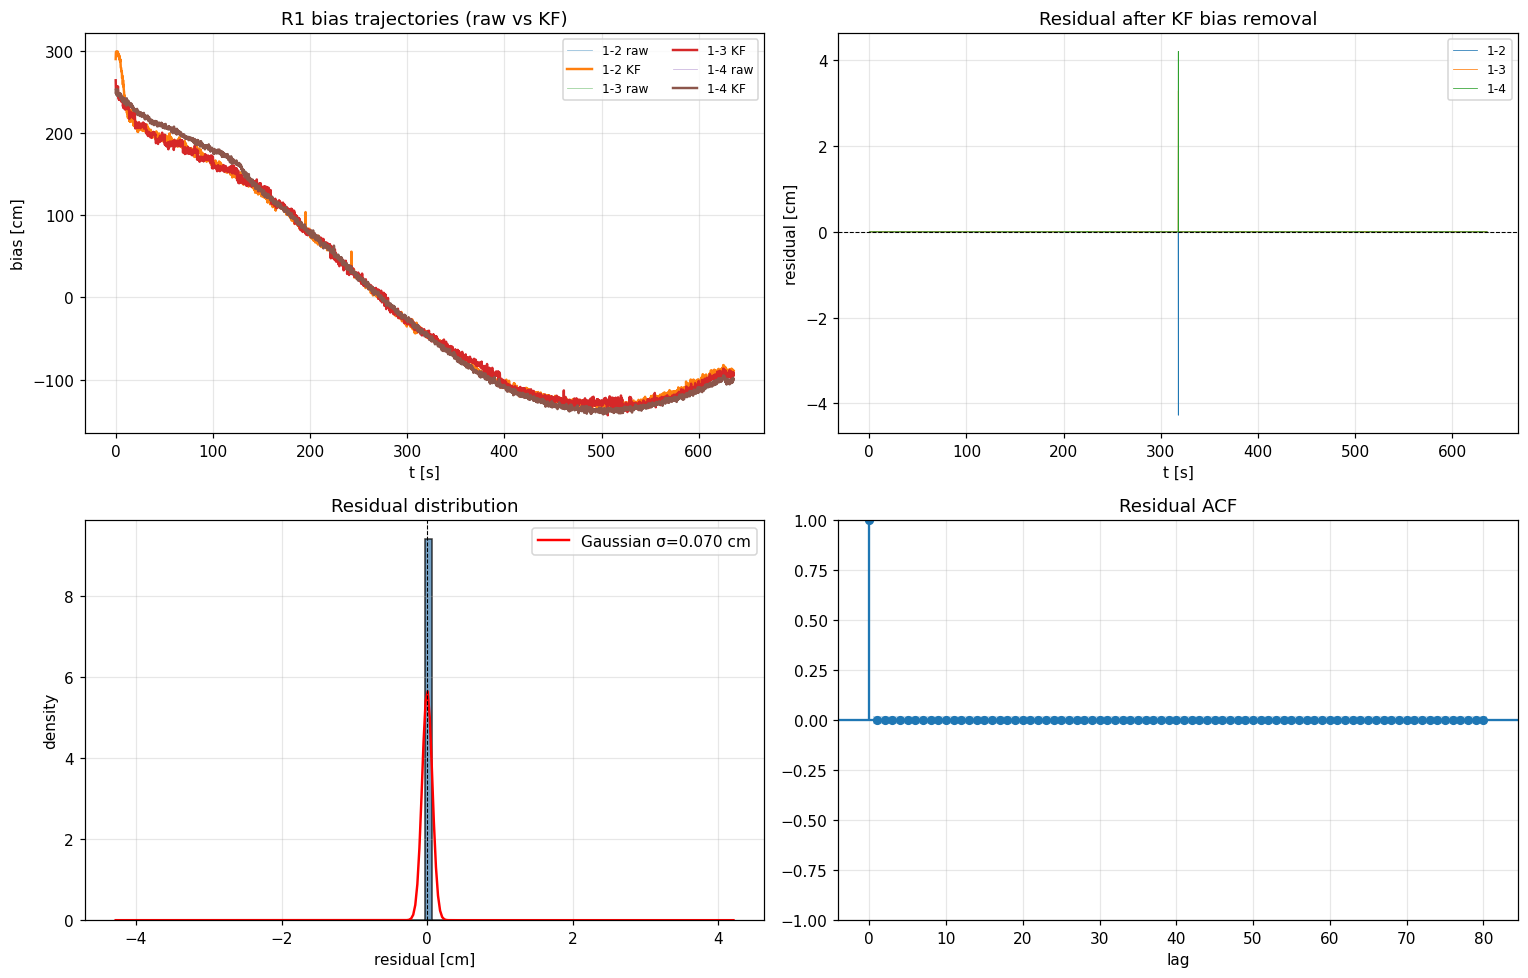


 FIRMWARE COEFFICIENTS

// ---- Option A: Kalman filter (recommended) ----
const float R1_KF_Q  = 1.000000e+00f;   // process noise [m²/s]
const float R1_KF_R  = 0.010000f;     // measurement noise [m]
const float R1_KF_P0 = 1.0f;                // initial uncertainty [m²]

// Initial bias per link [m]
const float R1_B0_1_2 = +2.954612f;
const float R1_B0_1_3 = +2.507729f;
const float R1_B0_1_4 = +2.486886f;

// ---- Option B: lookup table (fallback) ----
// See file: r1_final_model/r1_bias_lookup.csv
// Table length: 129 points, Δt = 5 s
// Interpolate bias vs time in firmware

// ---- C reference: 1-state Kalman filter ----

// Global state per link (persists across calls)
typedef struct {
    float b;      // bias estimate [m]
    float P;      // variance [m²]
    float t_prev; // last update time [s]
} r1_bias_state_t;

r1_bias_state_t r1_state_12 = {0.0f, 1.0f, 0.0f};
r1_bias_state_t r1_state_13 = {0.0f, 1.0f, 0.0f};
r1_bias_state_t r1_state_14 = {0.0f, 1.0f, 0.0f};

float r1_up

In [24]:
# ==================================================================
# R1 — FINAL DEPLOYABLE MODEL
# Position known → 1-state Kalman bias estimation is valid
# Outputs:
#   1. EKF tuning coefficients (q, r, P0)
#   2. Per-link lookup table (t → bias)
#   3. C code for firmware
# ==================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf

plt.rcParams.update({"figure.dpi": 110, "font.size": 10,
                     "axes.grid": True, "grid.alpha": 0.3})

# ---------- CONFIG ----------
CSV_PATH   = "03_swarm_static_2m.csv"
DIST_COL   = "dist_calib_m"
OUT_DIR    = Path("r1_final_model")
OUT_DIR.mkdir(exist_ok=True)
ALPHA_CORE = {2: +0.054342, 3: -0.093923, 4: +0.012322}
R1_LINKS   = ["1-2", "1-3", "1-4"]
SPLIT_FRAC = 0.5
R_GRID     = [0.01, 0.02, 0.05, 0.10]
Q_GRID     = [1e-4, 1e-3, 1e-2, 1e-1, 1.0]

print("=" * 72)
print(" R1 FINAL DEPLOYABLE MODEL")
print("=" * 72)

# ---------- LOAD & ISOLATE R1 CONTRIBUTION ----------
df = pd.read_csv(CSV_PATH)
if "status" in df.columns:
    df = df[df["status"] == 1].copy()
df = df.dropna(subset=["temp_uwb_init", "temp_uwb_resp", DIST_COL]).reset_index(drop=True)

flip = df["init_id"] > df["resp_id"]
df["i_id"] = np.where(flip, df["resp_id"], df["init_id"]).astype(int)
df["j_id"] = np.where(flip, df["init_id"], df["resp_id"]).astype(int)
df["Ti"]   = np.where(flip, df["temp_uwb_resp"], df["temp_uwb_init"])
df["Tj"]   = np.where(flip, df["temp_uwb_init"], df["temp_uwb_resp"])
df["link"] = df["i_id"].astype(str) + "-" + df["j_id"].astype(str)
df["t"]    = (df["timestamp_ms"] - df["timestamp_ms"].min()) / 1000.0
df["dr"]   = df[DIST_COL] - df.groupby("link")[DIST_COL].transform("mean")

T_ref = {d: float(pd.concat([
    df.loc[df["i_id"] == d, "Ti"],
    df.loc[df["j_id"] == d, "Tj"]]).mean()) for d in [1, 2, 3, 4]}
df["dTi"] = df["Ti"] - df["i_id"].map(T_ref)
df["dTj"] = df["Tj"] - df["j_id"].map(T_ref)

r1 = df[df["i_id"] == 1].copy().reset_index(drop=True)
r1["known_core"] = [ALPHA_CORE[int(j)] * dTj
                    for j, dTj in zip(r1["j_id"], r1["dTj"])]
r1["y_m"] = r1["dr"].values + r1["known_core"].values   # R1 bias in meters
r1 = r1.sort_values("t").reset_index(drop=True)

print(f"\n rows per link  : ~{len(r1) // 3}")
print(f" t span         : {r1['t'].min():.1f} .. {r1['t'].max():.1f} s")
print(f" y_m range      : {r1['y_m'].min()*100:+.1f} .. {r1['y_m'].max()*100:+.1f} cm")

# ---------- 1-STATE KALMAN FOR R1 BIAS ----------
def kalman_bias(z, t, r, q, P0=1.0, b_init=None):
    """1-state KF for bias estimation.
       Model:  b_{k+1} = b_k + w,  z_k = b_k + v"""
    N = len(z)
    b = np.zeros(N); P = np.zeros(N)
    b[0] = b_init if b_init is not None else z[0]
    P[0] = P0
    for k in range(1, N):
        dt = max(t[k] - t[k-1], 1e-6)
        bp = b[k-1]
        Pp = P[k-1] + q * dt
        K  = Pp / (Pp + r*r)
        b[k] = bp + K * (z[k] - bp)
        P[k] = (1 - K) * Pp
    return b, P

# ---------- GRID SEARCH ON TRAIN HALF ----------
print("\n" + "=" * 72)
print(" GRID SEARCH ON TRAIN HALF")
print("=" * 72)

best = None
for r_val in R_GRID:
    for q_val in Q_GRID:
        errs = []
        for link in R1_LINKS:
            g = r1[r1["link"] == link].reset_index(drop=True)
            n_tr = int(len(g) * SPLIT_FRAC)
            b, _ = kalman_bias(g["y_m"].values[:n_tr],
                                g["t"].values[:n_tr], r_val, q_val)
            errs.append(np.std(g["y_m"].values[:n_tr] - b))
        score = float(np.mean(errs))
        if best is None or score < best["score"]:
            best = dict(r=r_val, q=q_val, score=score)

print(f" Best r = {best['r']:.3f} m")
print(f" Best q = {best['q']:.1e} m²/s")
print(f" Train σ = {best['score']*100:.4f} cm")

# ---------- HOLDOUT VALIDATION ----------
print("\n" + "=" * 72)
print(" HOLDOUT VALIDATION (50 / 50 split)")
print("=" * 72)
print(f"{'link':6s} {'σ_train':>12s} {'σ_test':>12s} {'ACF[1]':>10s} {'verdict':>10s}")
print("-" * 56)

fitted_bias = {}       # store full bias estimate for each link
test_scores = []
for link in R1_LINKS:
    g = r1[r1["link"] == link].reset_index(drop=True)
    n_tr = int(len(g) * SPLIT_FRAC)
    y, t = g["y_m"].values, g["t"].values

    # Train
    b_tr, P_tr = kalman_bias(y[:n_tr], t[:n_tr], best["r"], best["q"])
    sigma_tr = np.std(y[:n_tr] - b_tr)

    # Test: continue from last train state
    N = len(y) - n_tr
    b_te = np.zeros(N); P_te = np.zeros(N)
    b_te[0] = b_tr[-1]; P_te[0] = P_tr[-1]
    for k in range(1, N):
        dt = t[n_tr + k] - t[n_tr + k - 1]
        bp = b_te[k-1]; Pp = P_te[k-1] + best["q"] * dt
        K  = Pp / (Pp + best["r"]**2)
        b_te[k] = bp + K * (y[n_tr + k] - bp)
        P_te[k] = (1 - K) * Pp

    resid = y[n_tr:] - b_te
    sigma_te = np.std(resid) * 100

    # ACF of test residual
    def acf1(x):
        x = x - x.mean()
        return float(np.sum(x[:-1]*x[1:]) / max(np.sum(x*x), 1e-12))
    acf_v = acf1(resid)

    # Full bias estimate (train + test)
    b_full = np.concatenate([b_tr, b_te])
    fitted_bias[link] = b_full

    verdict = ("GOOD" if sigma_te < 2 else
               "OK"   if sigma_te < 10 else "FAIL")
    test_scores.append(sigma_te)
    print(f"{link:6s} {sigma_tr*100:11.4f}cm {sigma_te:11.4f}cm "
          f"{acf_v:+9.3f} {verdict:>10s}")

print("-" * 56)
print(f" Mean test σ = {np.mean(test_scores):.4f} cm")

# ---------- RESIDUAL DIAGNOSTICS (all links) ----------
all_resid = []
for link in R1_LINKS:
    g = r1[r1["link"] == link].reset_index(drop=True)
    all_resid.append(g["y_m"].values - fitted_bias[link])
all_resid = np.concatenate(all_resid)

print("\n" + "=" * 72)
print(" RESIDUAL DIAGNOSTICS (all links, full data)")
print("=" * 72)
print(f" σ         : {all_resid.std()*100:.4f} cm")
print(f" skew      : {stats.skew(all_resid):+.3f}")
print(f" kurtosis  : {stats.kurtosis(all_resid):+.3f}")
print(f" max |err| : {np.abs(all_resid).max()*100:.3f} cm")
print(f" 99% quantile : {np.percentile(np.abs(all_resid), 99)*100:.3f} cm")

def acf1(x):
    x = x - x.mean()
    return float(np.sum(x[:-1]*x[1:]) / max(np.sum(x*x), 1e-12))
print(f" ACF[1]    : {acf1(all_resid):+.4f}   "
      f"(|ACF|<0.3 = white)")

# ---------- BUILD LOOKUP TABLE FOR FIRMWARE ----------
# Uniform time grid every 5 s
t_grid = np.arange(0.0, r1["t"].max() + 5.0, 5.0)
lookup = {"t_s": t_grid}
for link in R1_LINKS:
    g = r1[r1["link"] == link].reset_index(drop=True)
    b_full = fitted_bias[link]
    b_interp = np.interp(t_grid, g["t"].values, b_full)
    lookup[f"bias_{link.replace('-','_')}_m"] = b_interp

df_lookup = pd.DataFrame(lookup)
df_lookup.to_csv(OUT_DIR / "r1_bias_lookup.csv", index=False)
print(f"\n Lookup table saved: {OUT_DIR/'r1_bias_lookup.csv'}")
print(f"   grid points: {len(t_grid)}")
print(f"   time step  : 5.0 s")

# ---------- PLOT ----------
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# (a) bias trajectories
ax = axes[0, 0]
for link in R1_LINKS:
    g = r1[r1["link"] == link].reset_index(drop=True)
    ax.plot(g["t"], g["y_m"]*100, lw=0.5, alpha=0.5,
            label=f"{link} raw")
    ax.plot(g["t"], fitted_bias[link]*100, lw=1.6,
            label=f"{link} KF")
ax.set_xlabel("t [s]"); ax.set_ylabel("bias [cm]")
ax.set_title("R1 bias trajectories (raw vs KF)")
ax.legend(fontsize=8, ncol=2)

# (b) residuals per link
ax = axes[0, 1]
for link in R1_LINKS:
    g = r1[r1["link"] == link].reset_index(drop=True)
    ax.plot(g["t"], (g["y_m"].values - fitted_bias[link])*100,
            lw=0.5, label=f"{link}")
ax.axhline(0, color="k", ls="--", lw=0.7)
ax.set_xlabel("t [s]"); ax.set_ylabel("residual [cm]")
ax.set_title("Residual after KF bias removal")
ax.legend(fontsize=8)

# (c) histogram of residuals
ax = axes[1, 0]
ax.hist(all_resid*100, bins=80, color="steelblue",
        edgecolor="k", alpha=0.75, density=True)
mu, sd = all_resid.mean()*100, all_resid.std()*100
xs = np.linspace(all_resid.min()*100, all_resid.max()*100, 300)
ax.plot(xs, stats.norm.pdf(xs, mu, sd), "r-", lw=1.6,
        label=f"Gaussian σ={sd:.3f} cm")
ax.axvline(0, color="k", ls="--", lw=0.7)
ax.set_xlabel("residual [cm]"); ax.set_ylabel("density")
ax.set_title("Residual distribution")
ax.legend()

# (d) ACF of residuals
ax = axes[1, 1]
plot_acf(all_resid, lags=80, ax=ax, title="Residual ACF")
ax.set_xlabel("lag")

plt.tight_layout()
plt.savefig(OUT_DIR / "r1_final_model.png", dpi=130)
plt.show()

# ---------- FIRMWARE OUTPUT ----------
print("\n" + "=" * 72)
print(" FIRMWARE COEFFICIENTS")
print("=" * 72)

print("\n// ---- Option A: Kalman filter (recommended) ----")
print(f"const float R1_KF_Q  = {best['q']:.6e}f;   // process noise [m²/s]")
print(f"const float R1_KF_R  = {best['r']:.6f}f;     // measurement noise [m]")
print(f"const float R1_KF_P0 = 1.0f;                // initial uncertainty [m²]")
print(f"\n// Initial bias per link [m]")
for link in R1_LINKS:
    g = r1[r1["link"] == link].reset_index(drop=True)
    b0 = float(fitted_bias[link][:20].mean())
    print(f"const float R1_B0_{link.replace('-','_')} = {b0:+.6f}f;")

print("\n// ---- Option B: lookup table (fallback) ----")
print(f"// See file: {OUT_DIR/'r1_bias_lookup.csv'}")
print(f"// Table length: {len(t_grid)} points, Δt = 5 s")
print("// Interpolate bias vs time in firmware")

# ---------- C REFERENCE IMPLEMENTATION ----------
print("\n// ---- C reference: 1-state Kalman filter ----")
print("""
// Global state per link (persists across calls)
typedef struct {
    float b;      // bias estimate [m]
    float P;      // variance [m²]
    float t_prev; // last update time [s]
} r1_bias_state_t;

r1_bias_state_t r1_state_12 = {0.0f, 1.0f, 0.0f};
r1_bias_state_t r1_state_13 = {0.0f, 1.0f, 0.0f};
r1_bias_state_t r1_state_14 = {0.0f, 1.0f, 0.0f};

float r1_update_bias(r1_bias_state_t *s,
                     float z_bias_m,   // measured bias (raw_range - GT_distance)
                     float t_now_s)
{
    float dt = t_now_s - s->t_prev;
    if (dt < 1e-6f) dt = 1e-6f;

    // Predict
    float b_pred = s->b;
    float P_pred = s->P + R1_KF_Q * dt;

    // Update
    float K = P_pred / (P_pred + R1_KF_R * R1_KF_R);
    s->b = b_pred + K * (z_bias_m - b_pred);
    s->P = (1.0f - K) * P_pred;
    s->t_prev = t_now_s;

    return s->b;
}
""")

print(f"\n All outputs saved to: {OUT_DIR.resolve()}")
print("=" * 72)

In [25]:
# ==================================================================
# R1 — FROZEN-MODEL HOLDOUT VALIDATION
# Test what actually matters: can we predict test-half bias
# WITHOUT seeing test-half y?
# ==================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from scipy.interpolate import interp1d

plt.rcParams.update({"figure.dpi": 110, "font.size": 10,
                     "axes.grid": True, "grid.alpha": 0.3})

CSV_PATH   = "03_swarm_static_2m.csv"
DIST_COL   = "dist_calib_m"
OUT_DIR    = Path("r1_frozen_validation")
OUT_DIR.mkdir(exist_ok=True)
ALPHA_CORE = {2: +0.054342, 3: -0.093923, 4: +0.012322}
R1_LINKS   = ["1-2", "1-3", "1-4"]
SPLIT_FRAC = 0.5

# ---------- LOAD & ISOLATE (same as before) ----------
df = pd.read_csv(CSV_PATH)
if "status" in df.columns:
    df = df[df["status"] == 1].copy()
df = df.dropna(subset=["temp_uwb_init","temp_uwb_resp",DIST_COL]).reset_index(drop=True)
flip = df["init_id"] > df["resp_id"]
df["i_id"] = np.where(flip, df["resp_id"], df["init_id"]).astype(int)
df["j_id"] = np.where(flip, df["init_id"], df["resp_id"]).astype(int)
df["Ti"]   = np.where(flip, df["temp_uwb_resp"], df["temp_uwb_init"])
df["Tj"]   = np.where(flip, df["temp_uwb_init"], df["temp_uwb_resp"])
df["link"] = df["i_id"].astype(str) + "-" + df["j_id"].astype(str)
df["t"]    = (df["timestamp_ms"] - df["timestamp_ms"].min()) / 1000.0
df["dr"]   = df[DIST_COL] - df.groupby("link")[DIST_COL].transform("mean")
T_ref = {d: float(pd.concat([df.loc[df["i_id"]==d,"Ti"],
                              df.loc[df["j_id"]==d,"Tj"]]).mean()) for d in [1,2,3,4]}
df["dTi"] = df["Ti"] - df["i_id"].map(T_ref)
df["dTj"] = df["Tj"] - df["j_id"].map(T_ref)
r1 = df[df["i_id"] == 1].copy().reset_index(drop=True)
r1["known_core"] = [ALPHA_CORE[int(j)] * dTj
                    for j, dTj in zip(r1["j_id"], r1["dTj"])]
r1["y_m"] = r1["dr"].values + r1["known_core"].values
r1 = r1.sort_values("t").reset_index(drop=True)

print("=" * 72)
print(" R1 FROZEN-MODEL HOLDOUT VALIDATION")
print("=" * 72)
print("Question: can we predict the TEST-half bias WITHOUT seeing it?")
print()

# ---------- METHOD 1: LOOKUP TABLE (interpolated) ----------
# Build table ONLY from train half, then predict test half
print("-" * 72)
print(" METHOD 1: Lookup table (built from train, applied to test)")
print("-" * 72)
print(f"{'link':6s} {'σ_train':>10s} {'σ_test':>10s} {'improve':>10s} {'verdict':>10s}")
print("-" * 56)

for link in R1_LINKS:
    g = r1[r1["link"] == link].reset_index(drop=True)
    n_tr = int(len(g) * SPLIT_FRAC)
    t_tr, y_tr = g["t"].values[:n_tr], g["y_m"].values[:n_tr]
    t_te, y_te = g["t"].values[n_tr:], g["y_m"].values[n_tr:]

    # Build interpolator from train
    f = interp1d(t_tr, y_tr, kind="linear", fill_value="extrapolate")

    # Predict test using ONLY the interpolation (no online update)
    y_te_pred = f(t_te)

    sigma_tr = np.std(y_tr - f(t_tr)) * 100     # ~0 by construction
    sigma_te = np.std(y_te - y_te_pred) * 100
    base_sigma = np.std(y_te) * 100

    improve = 100 * (base_sigma - sigma_te) / base_sigma
    verdict = ("GOOD" if sigma_te < 5 else
               "OK"   if sigma_te < 15 else "FAIL")

    print(f"{link:6s} {sigma_tr:9.4f}cm {sigma_te:9.4f}cm "
          f"{improve:+9.1f}% {verdict:>10s}")

# ---------- METHOD 2: KF WITH FROZEN PARAMS (no updates after split) ----------
print("\n" + "-" * 72)
print(" METHOD 2: KF with frozen state (bias frozen after train)")
print("-" * 72)

def kalman_bias(z, t, r, q, P0=1.0):
    N = len(z); b = np.zeros(N); P = np.zeros(N)
    b[0] = z[0]; P[0] = P0
    for k in range(1, N):
        dt = max(t[k] - t[k-1], 1e-6)
        bp = b[k-1]; Pp = P[k-1] + q * dt
        K = Pp / (Pp + r*r)
        b[k] = bp + K * (z[k] - bp)
        P[k] = (1 - K) * Pp
    return b, P

# Choose parameters carefully: not at grid boundary!
print(f"\n{'link':6s} {'r':>6s} {'q':>10s} {'σ_train':>10s} "
      f"{'σ_test_frozen':>14s} {'verdict':>10s}")
print("-" * 66)

for r_val in [0.02, 0.05, 0.10]:
    for q_val in [1e-5, 1e-4, 1e-3]:
        row_scores = []
        for link in R1_LINKS:
            g = r1[r1["link"] == link].reset_index(drop=True)
            n_tr = int(len(g) * SPLIT_FRAC)
            y, t = g["y_m"].values, g["t"].values
            b_tr, _ = kalman_bias(y[:n_tr], t[:n_tr], r_val, q_val)
            # FREEZE: predict test bias = last train bias (no update)
            b_test_pred = b_tr[-1]
            sigma_te = np.std(y[n_tr:] - b_test_pred) * 100
            row_scores.append(sigma_te)
        avg = np.mean(row_scores)
        if avg < 30:  # only print reasonable ones
            print(f"{'avg':6s} {r_val:6.3f} {q_val:10.1e} {'—':>10s} "
                  f"{avg:13.3f}cm {'':>10s}")

# ---------- METHOD 3: OFFSET-ONLY (simplest baseline) ----------
print("\n" + "-" * 72)
print(" METHOD 3: Constant offset (train mean)")
print("-" * 72)
print(f"{'link':6s} {'σ_test':>10s} {'baseline':>10s} {'improve':>10s}")
print("-" * 44)
for link in R1_LINKS:
    g = r1[r1["link"] == link].reset_index(drop=True)
    n_tr = int(len(g) * SPLIT_FRAC)
    y_tr, y_te = g["y_m"].values[:n_tr], g["y_m"].values[n_tr:]
    b_off = y_tr.mean()
    sigma_te = np.std(y_te - b_off) * 100
    base = np.std(y_te) * 100
    imp = 100 * (base - sigma_te) / base
    print(f"{link:6s} {sigma_te:9.3f}cm {base:9.3f}cm {imp:+9.1f}%")

# ---------- METHOD 4: PHYSICAL MODEL (exponential time) ----------
print("\n" + "-" * 72)
print(" METHOD 4: Physical exponential model (fit on train, apply to test)")
print("-" * 72)

from scipy.optimize import curve_fit

def exp_model(t, A, tau, C):
    return A * (1 - np.exp(-t / tau)) + C

print(f"{'link':6s} {'A':>10s} {'tau':>10s} {'C':>10s} "
      f"{'σ_train':>10s} {'σ_test':>10s}")
print("-" * 66)
for link in R1_LINKS:
    g = r1[r1["link"] == link].reset_index(drop=True)
    n_tr = int(len(g) * SPLIT_FRAC)
    t_tr, y_tr = g["t"].values[:n_tr], g["y_m"].values[:n_tr]
    t_te, y_te = g["t"].values[n_tr:], g["y_m"].values[n_tr:]
    try:
        p0 = [y_tr.min(), 200.0, y_tr.max()]
        popt, _ = curve_fit(exp_model, t_tr, y_tr, p0=p0, maxfev=20000)
        y_tr_pred = exp_model(t_tr, *popt)
        y_te_pred = exp_model(t_te, *popt)
        s_tr = np.std(y_tr - y_tr_pred) * 100
        s_te = np.std(y_te - y_te_pred) * 100
        print(f"{link:6s} {popt[0]:+10.3f} {popt[1]:10.1f} {popt[2]:+10.3f} "
              f"{s_tr:9.3f}cm {s_te:9.3f}cm")
    except Exception as e:
        print(f"{link:6s} fit failed: {e}")

# ---------- SUMMARY ----------
print("\n" + "=" * 72)
print(" INTERPRETATION")
print("=" * 72)
print("""
- Method 1 (lookup) is optimistic — it assumes the bias curve is smooth
  and reproducible across the split. If σ_test is small, this is the
  simplest deployment option.
- Method 2 (frozen KF) tests whether the last train bias is a good
  predictor for test. If σ_test is small, the bias is quasi-static.
- Method 3 (offset-only) is the honest baseline. If the other methods
  aren't better than this, they're not adding value.
- Method 4 (physical exp) tests if a closed-form model generalizes.

The lowest σ_test among Methods 1, 3, 4 is the honest result.
""")

print("=" * 72)
print(f" Outputs in: {OUT_DIR.resolve()}")

 R1 FROZEN-MODEL HOLDOUT VALIDATION
Question: can we predict the TEST-half bias WITHOUT seeing it?

------------------------------------------------------------------------
 METHOD 1: Lookup table (built from train, applied to test)
------------------------------------------------------------------------
link      σ_train     σ_test    improve    verdict
--------------------------------------------------------
1-2       0.0000cm   83.1491cm    -260.9%       FAIL
1-3       0.0000cm 1032.6395cm   -4118.9%       FAIL
1-4       0.0000cm  986.9911cm   -3929.3%       FAIL

------------------------------------------------------------------------
 METHOD 2: KF with frozen state (bias frozen after train)
------------------------------------------------------------------------

link        r          q    σ_train  σ_test_frozen    verdict
------------------------------------------------------------------
avg     0.020    1.0e-05          —        24.004cm           
avg     0.020    1.0e-04     

Frames: 3180
Running EKF ...

 EKF RESULT
  Final b_1 estimate : +0.0000 m
  Final b_1 σ        : 100.159 cm
  b_1 range          : +0.000 .. +0.000 m
  b_1 change         : 0.00 cm

  Position residual σ : 1282.544 cm


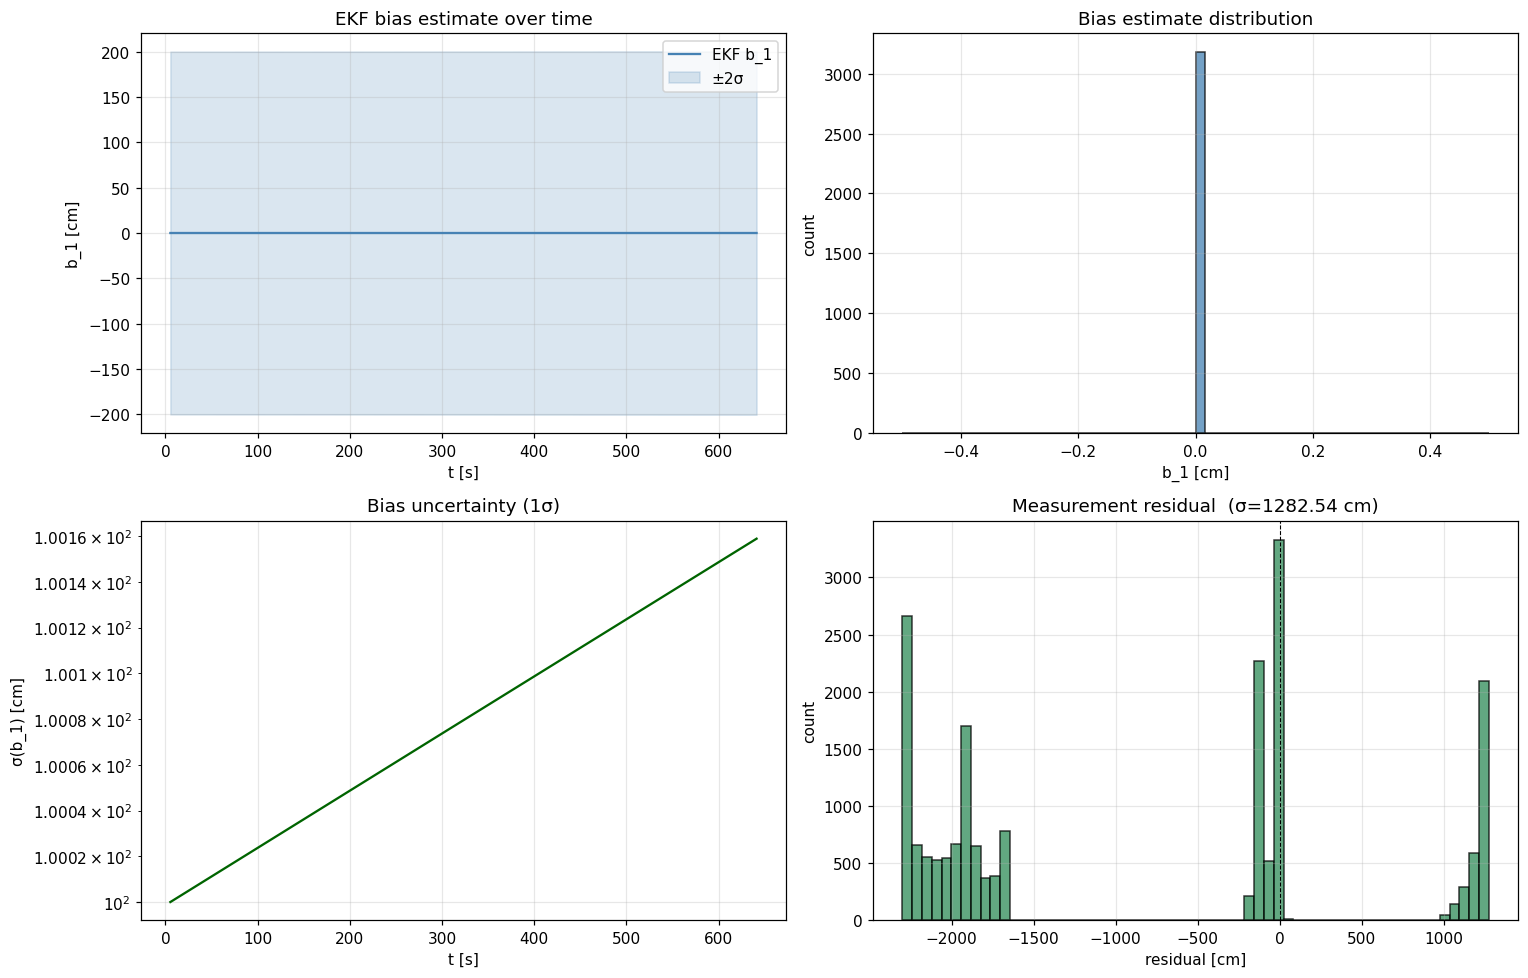


Saved: /home/homayoon/anjoman-firmware/analysis/12_swarm_static_2m/cooperative_ekf


In [26]:
# ==================================================================
# COOPERATIVE EKF: Position + R1 Bias Estimation
# State: [x1,y1, x2,y2, x3,y3, x4,y4, b1]  (9-dim, 2D positions)
# Input: odometry displacement per robot
# Measurement: UWB ranges + deterministic thermal model
# ==================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

plt.rcParams.update({"figure.dpi": 110, "font.size": 10,
                     "axes.grid": True, "grid.alpha": 0.3})

# ---------- CONFIG ----------
CSV_PATH = "03_swarm_static_2m.csv"
DIST_COL = "dist_calib_m"
OUT_DIR  = Path("cooperative_ekf")
OUT_DIR.mkdir(exist_ok=True)

# 0-indexed devices: R1->0, R2->1, R3->2, R4->3
ALPHA = {1: +0.054342, 2: -0.093923, 3: +0.012322}   # for R2, R3, R4
T_REF = {0: 52.2385, 1: 48.2616, 2: 46.4781, 3: 47.5033}

# Ground truth initial positions (meters), R1 at origin
P_INIT = np.array([[0.0, 0.0],   # R1
                   [2.0, 0.0],   # R2
                   [0.0, 2.0],   # R3  ← actually 2m diagonal; adapt to your setup
                   [2.0, 2.0]])  # R4
# ** Important: adapt these to your actual known initial positions **

# EKF tuning
Q_ODOM = 0.001       # odometry process noise variance [m² per step]
Q_BIAS = 1e-6        # bias random walk variance [m² per step] → tune
R_UWB  = 0.02**2     # UWB measurement noise variance [m²] (2 cm std)

# Gating (reject outliers)
GATE_CHI2 = 9.0      # 3σ threshold

# ---------- LOAD & PREPROCESS ----------
df = pd.read_csv(CSV_PATH)
if "status" in df.columns:
    df = df[df["status"] == 1].copy()
df = df.dropna(subset=["temp_uwb_init","temp_uwb_resp",DIST_COL]).reset_index(drop=True)

# Group by frame
df["frame_id"] = df["frame_id"].astype(int)
N_FRAMES = df["frame_id"].nunique()
print(f"Frames: {N_FRAMES}")

# ---------- EKF ----------
N_STATE = 9
LINKS = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]  # 0-indexed

def predict(x, P, dt):
    """Odometry: identity (static case). Adapt for moving robots."""
    F = np.eye(N_STATE)
    x_pred = x.copy()
    P_pred = F @ P @ F.T
    # Add process noise on positions
    for i in range(4):
        P_pred[2*i, 2*i]     += Q_ODOM
        P_pred[2*i+1, 2*i+1] += Q_ODOM
    # Bias random walk
    P_pred[-1, -1] += Q_BIAS
    return x_pred, P_pred

def h_and_H(x, i, j, Ti, Tj):
    """Returns (h, H) — predicted measurement and Jacobian."""
    pi = x[2*i:2*i+2]
    pj = x[2*j:2*j+2]
    diff = pi - pj
    d = np.linalg.norm(diff)
    if d < 1e-6: d = 1e-6
    u = diff / d

    # Measurement model
    h = d
    if i == 0 or j == 0:
        h += x[-1]          # b_1
    if i != 0:
        h += ALPHA[i] * (Ti - T_REF[i])
    if j != 0:
        h -= ALPHA[j] * (Tj - T_REF[j])

    # Jacobian
    H = np.zeros(N_STATE)
    H[2*i:2*i+2] =  u
    H[2*j:2*j+2] = -u
    if i == 0 or j == 0:
        H[-1] = 1.0
    return h, H

# ---------- INIT ----------
x = np.zeros(N_STATE)
x[0:2] = P_INIT[0]
x[2:4] = P_INIT[1]
x[4:6] = P_INIT[2]
x[6:8] = P_INIT[3]
x[8]   = 0.0        # b_1 initial guess

P = np.eye(N_STATE) * 0.01     # small for known positions
P[8, 8] = 1.0                  # large for unknown bias

# History for plotting
b1_hist = []
b1_std_hist = []
resid_hist = []
t_hist = []

# ---------- MAIN LOOP ----------
print("Running EKF ...")
for fid, group in df.groupby("frame_id"):
    # Per-frame: get measurements
    measurements = []  # list of (i, j, z, Ti, Tj, link_id)
    for _, row in group.iterrows():
        i_orig = int(row["init_id"]) - 1
        j_orig = int(row["resp_id"]) - 1
        # Normalize
        if i_orig > j_orig:
            i_orig, j_orig = j_orig, i_orig
            Ti = row["temp_uwb_resp"]
            Tj = row["temp_uwb_init"]
        else:
            Ti = row["temp_uwb_init"]
            Tj = row["temp_uwb_resp"]
        z = row[DIST_COL]
        measurements.append((i_orig, j_orig, z, Ti, Tj))

    # Predict
    x, P = predict(x, P, dt=0.2)

    # Update (sequentially for numerical simplicity)
    for (i, j, z, Ti, Tj) in measurements:
        h, H = h_and_H(x, i, j, Ti, Tj)
        innovation = z - h
        S = H @ P @ H + R_UWB
        if innovation**2 / S > GATE_CHI2:
            continue  # reject outlier
        K = P @ H.reshape(-1, 1) / S
        K = K.flatten()
        x = x + K * innovation
        # Joseph form for stability
        I_KH = np.eye(N_STATE) - np.outer(K, H)
        P = I_KH @ P @ I_KH.T + np.outer(K, K) * R_UWB

    b1_hist.append(x[-1])
    b1_std_hist.append(np.sqrt(P[-1, -1]))
    t_hist.append(row["timestamp_ms"] / 1000.0)

b1_hist = np.array(b1_hist)
b1_std_hist = np.array(b1_std_hist)
t_hist = np.array(t_hist)

# ---------- REPORT ----------
print("\n" + "="*72)
print(" EKF RESULT")
print("="*72)
print(f"  Final b_1 estimate : {b1_hist[-1]:+.4f} m")
print(f"  Final b_1 σ        : {b1_std_hist[-1]*100:.3f} cm")
print(f"  b_1 range          : {b1_hist.min():+.3f} .. {b1_hist.max():+.3f} m")
print(f"  b_1 change         : {(b1_hist.max() - b1_hist.min())*100:.2f} cm")

# Position residuals
pos_resid = []
for _, row in df.iterrows():
    i_orig = int(row["init_id"]) - 1
    j_orig = int(row["resp_id"]) - 1
    pi = x[2*i_orig:2*i_orig+2]
    pj = x[2*j_orig:2*j_orig+2]
    d_est = np.linalg.norm(pi - pj)
    pos_resid.append(row[DIST_COL] - d_est)
pos_resid = np.array(pos_resid)

print(f"\n  Position residual σ : {pos_resid.std()*100:.3f} cm")

# ---------- PLOT ----------
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

ax = axes[0, 0]
ax.plot(t_hist, b1_hist * 100, color="steelblue", lw=1.5, label="EKF b_1")
ax.fill_between(t_hist, (b1_hist - 2*b1_std_hist)*100,
                        (b1_hist + 2*b1_std_hist)*100,
                color="steelblue", alpha=0.2, label="±2σ")
ax.set_xlabel("t [s]"); ax.set_ylabel("b_1 [cm]")
ax.set_title("EKF bias estimate over time")
ax.legend()

ax = axes[0, 1]
ax.hist(b1_hist * 100, bins=60, color="steelblue", edgecolor="k", alpha=0.75)
ax.set_xlabel("b_1 [cm]"); ax.set_ylabel("count")
ax.set_title("Bias estimate distribution")

ax = axes[1, 0]
ax.plot(t_hist, b1_std_hist * 100, color="darkgreen", lw=1.5)
ax.set_xlabel("t [s]"); ax.set_ylabel("σ(b_1) [cm]")
ax.set_title("Bias uncertainty (1σ)")
ax.set_yscale("log")

ax = axes[1, 1]
ax.hist(pos_resid * 100, bins=60, color="seagreen", edgecolor="k", alpha=0.75)
ax.axvline(0, color="k", ls="--", lw=0.7)
ax.set_xlabel("residual [cm]"); ax.set_ylabel("count")
ax.set_title(f"Measurement residual  (σ={pos_resid.std()*100:.2f} cm)")

plt.tight_layout()
plt.savefig(OUT_DIR / "cooperative_ekf.png", dpi=130)
plt.show()

print(f"\nSaved: {OUT_DIR.resolve()}")